# Pipeline Kmeans y DBscan Run
- Todos Los Modelos Balanceados
-  DATA PREPARATION
-  Constantes modelos pipeline
-  Pipeline
 - OrdinalEncoder
 - ColumnTransformer
 - Seleccion y extracción de de caracteriticas
 - Standard Scaler
- Kmeans
- Dbscan

In [1]:
pip install tensorflow

Note: you may need to restart the kernel to use updated packages.


In [2]:
import tensorflow as tf
print(tf.__version__)

2.21.0


In [3]:
pip install scikit-learn==1.6.1

Note: you may need to restart the kernel to use updated packages.


In [4]:
pip install shap

Note: you may need to restart the kernel to use updated packages.


In [5]:
pip install gputil

Note: you may need to restart the kernel to use updated packages.


In [6]:
import numpy as np
import pandas as pd
from sklearn import utils
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.cluster import KMeans
import shap
shap.initjs()
import warnings
warnings.filterwarnings('ignore')

# scikit-learn==1.6.1
# from sinfo import sinfo
# sinfo()
# import sklearn
# sklearn.show_versions()

In [7]:
import sklearn
print("Versión de scikit-learn:", sklearn.__version__)

Versión de scikit-learn: 1.6.1


In [8]:
import sys
sys.path.insert(0, 'C:/Users/Usuario/Downloads/Notebooks de Alex')

import metricas
from sklearn import metrics
import psutil
import GPUtil
import time

start_time = time.time()
psutil.cpu_times()
psutil.virtual_memory()
psutil.disk_partitions()

t_cpu = psutil.cpu_times()
cpu_usage = psutil.cpu_percent(1)
mem_usage = psutil.virtual_memory().percent
disco2 = psutil.disk_usage('/')

In [9]:
import joblib
import os

def pickle_model(pkl_filename, operation, model):
    if operation == 'wb':
        with open(pkl_filename, operation) as file:
            joblib.dump(model, file)
        print('Modelo', pkl_filename, 'guardado.')
            
    elif operation == 'rb':
        with open(pkl_filename, operation) as file:
            joblib_model =joblib.load(file)
        print('Lectura de', pkl_filename, '.')
        return joblib_model

In [10]:
def new_categories(df,old_keys,new_keys):
    choices = ['DDoS_UDP','Reconnaissance','DDoS_TCP','UDP_Flood','ICMP_Flood']
    for i,v in enumerate(old_keys):
        condiciones = [
        df[ v ].str.contains('DDoS_UDP|DoS_UDP'),
        df[ v ].str.contains('Reconnaissance_OS_Fingerprint|Reconnaissance_Service_Scan'),
        df[ v ].str.contains('DDoS_TCP|DoS_TCP'),
        df[ v ] == 'UDP_Flood',
        df[ v ] == 'ICMP_Flood',
        ]
        df[new_keys[i]] = np.select(condiciones,choices, default='Normal')
        print(df[new_keys[i]].value_counts())

In [11]:
import os
import psutil
import time
import datetime

def cpu_info():
    cpu = psutil.Process(os.getpid()).cpu_percent (1) # tasa de uso de CPU en un segundo, unidad
    cpu_per = '% .2f %%'% cpu # se convierte en un porcentaje, mantenga dos decimales
    return (cpu_per , cpu)

def mem_info():
    mem = psutil.Process(os.getpid()).memory_percent()
    
    mem_per = '%.2f%%' % mem
    return (mem_per , mem)


def disk_info() :
    c_info = psutil.disk_usage('/')
    c_per = '%.2f%%' % c_info[3]
    return c_per


def medida_tiempo() :
    tiempo = datetime.datetime.now()
    return tiempo


def tiempo_total(t1 , t2) :
    t_total = t2 - t1
    return t_total


def children_process(cpu , mem) :
    c_list= []
    children_list = psutil.Process(os.getpid()).children()
    if len(children_list) > 0:
        for i in range( len (children_list) ):
            c_list += [children_list[ i ].pid]
        info_children = add_children(c_list , cpu , mem)
        return info_children
    else:
        return 'Not children'
    


def add_children(c_list , cpu , mem) :
    cpu_su = cpu[1]
    mem_su = mem[1]
    for i in range( len (c_list)):
        pid = c_list[i]
        cpu_child = psutil.Process(pid).cpu_percent (1)
        mem_child = psutil.Process( pid ).memory_percent()
#         print( cpu_child , mem_child )
        cpu_su += cpu_child
        mem_su += mem_child
    cpu_total = '%.2f%%' % cpu_su
    mem_total = '%.2f%%' % mem_su
    return (cpu_total , mem_total)   

def print_info(cpu , mem , disco , t , otro) :
    if otro == 'Not children':
        var_prin = f'cpu: {cpu[0]}, memoria: {mem[0]}, disco: {disco}, tiempo: {t}'
    if otro != 'Not children':
        var_prin = f'cpu: {otro[0]}, memoria: {otro[1]}, disco: {disco}, tiempo: {t}'
    return var_prin

if __name__ == '__main__' :
    t1 = medida_tiempo()
    cpu = cpu_info()
    mem = mem_info()
    disco = disk_info()
    otro = children_process(cpu , mem)
    t2 = medida_tiempo()
    t= tiempo_total(t1, t2)
    print_info(cpu , mem , disco , t , otro)

# DATA PREPARATION

In [12]:
df = pd.read_csv(
    'C:/Users/Usuario/Downloads/Notebooks de Alex/Datasets_Entrenamiento/dataset_entrenamiento_completo.csv'
)
df = utils.shuffle(df)
df.info()

<class 'pandas.DataFrame'>
Index: 344000 entries, 240305 to 188742
Data columns (total 27 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   delta_time       344000 non-null  float64
 1   protocols        344000 non-null  str    
 2   ip_src           344000 non-null  str    
 3   ip_dst           344000 non-null  str    
 4   port_src         344000 non-null  float64
 5   port_dst         344000 non-null  float64
 6   frame_len        344000 non-null  int64  
 7   udp_len          344000 non-null  float64
 8   ip_ttl           344000 non-null  float64
 9   icmp_type        344000 non-null  float64
 10  tos              344000 non-null  float64
 11  ip_flags_rb      344000 non-null  float64
 12  ip_flags_df      344000 non-null  float64
 13  ip_flags_mf      344000 non-null  float64
 14  tcp_flags_res    344000 non-null  float64
 15  tcp_flags_ns     344000 non-null  float64
 16  tcp_flags_cwr    344000 non-null  float64
 17  tc

In [13]:
df.tipo_ataque.value_counts()

tipo_ataque
Normal                           200000
DoS_UDP                           20000
Reconnaissance_OS_Fingerprint     20000
DDoS_TCP                          20000
Reconnaissance_Service_Scan       20000
DoS_TCP                           20000
DDoS_UDP                          20000
ICMP_Flood                        12000
UDP_Flood                         12000
Name: count, dtype: int64

In [14]:
df = df.drop(['ip_src', 'ip_dst','epoch_time' ],axis=1) # epoch_time tiempo maquina
lista=['ip_ttl',  'tos','ip_flags_rb','ip_flags_df','ip_flags_mf']
#tipo string, para reemplazar un coma por el punto y convertirlo en float
df[lista] = df[lista].astype('str')
df.ip_ttl = df.ip_ttl.str.replace(',','.')
df.tos = df.tos.str.replace(',','.')
df.ip_flags_rb = df.ip_flags_rb.str.replace(',','.')
df.ip_flags_df = df.ip_flags_df.str.replace(',','.')
df.ip_flags_mf = df.ip_flags_mf.str.replace(',','.')
df[lista] = df[lista].astype('float64')
df[lista].info()
len(df['protocols'].unique())

<class 'pandas.DataFrame'>
Index: 344000 entries, 240305 to 188742
Data columns (total 5 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   ip_ttl       344000 non-null  float64
 1   tos          344000 non-null  float64
 2   ip_flags_rb  344000 non-null  float64
 3   ip_flags_df  344000 non-null  float64
 4   ip_flags_mf  344000 non-null  float64
dtypes: float64(5)
memory usage: 15.7 MB


35

In [15]:
X = df.drop(['label','tipo_ataque', 'protocols'],axis=1)
y = y =df['label']
X

,delta_time,port_src,port_dst,frame_len,udp_len,ip_ttl,icmp_type,tos,ip_flags_rb,ip_flags_df,...,tcp_flags_res,tcp_flags_ns,tcp_flags_cwr,tcp_flags_ecn,tcp_flags_urg,tcp_flags_ack,tcp_flags_push,tcp_flags_reset,tcp_flags_syn,tcp_flags_fin
240305,0.000001,3179.0,80.0,60,8.0,64.0,-1.0,0.0,0.0,0.0,...,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0
339943,0.000982,-2.0,-2.0,60,-2.0,64.0,8.0,0.0,0.0,0.0,...,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0
230914,0.003414,55550.0,9100.0,60,-1.0,58.0,-1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
276121,0.000002,44174.0,80.0,154,-1.0,64.0,-1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
261364,0.000002,35198.0,80.0,154,-1.0,64.0,-1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
221596,0.000001,51137.0,55600.0,60,-1.0,39.0,-1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
103397,0.000001,365.0,565.0,60,26.0,127.0,-1.0,0.0,0.0,0.0,...,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0
142792,0.000006,3456.0,80.0,918,884.0,127.0,-1.0,0.0,0.0,0.0,...,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0
72922,0.000016,80.0,80.0,761,-1.0,127.0,-1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [16]:
print(y.value_counts())

label
0    200000
1    144000
Name: count, dtype: int64


In [17]:
print(df.columns.tolist())

['delta_time', 'protocols', 'port_src', 'port_dst', 'frame_len', 'udp_len', 'ip_ttl', 'icmp_type', 'tos', 'ip_flags_rb', 'ip_flags_df', 'ip_flags_mf', 'tcp_flags_res', 'tcp_flags_ns', 'tcp_flags_cwr', 'tcp_flags_ecn', 'tcp_flags_urg', 'tcp_flags_ack', 'tcp_flags_push', 'tcp_flags_reset', 'tcp_flags_syn', 'tcp_flags_fin', 'label', 'tipo_ataque']


In [18]:
new_categories(df,old_keys=['tipo_ataque'],    # lista de 1 element
               new_keys=['tipo_ataque2'])  # lista de 1 elemento
df

tipo_ataque2
Normal            200000
DDoS_UDP           40000
Reconnaissance     40000
DDoS_TCP           40000
ICMP_Flood         12000
UDP_Flood          12000
Name: count, dtype: int64


,delta_time,protocols,port_src,port_dst,frame_len,udp_len,ip_ttl,icmp_type,tos,ip_flags_rb,...,tcp_flags_ecn,tcp_flags_urg,tcp_flags_ack,tcp_flags_push,tcp_flags_reset,tcp_flags_syn,tcp_flags_fin,label,tipo_ataque,tipo_ataque2
240305,0.000001,UDP,3179.0,80.0,60,8.0,64.0,-1.0,0.0,0.0,...,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,1,DoS_UDP,DDoS_UDP
339943,0.000982,ICMP,-2.0,-2.0,60,-2.0,64.0,8.0,0.0,0.0,...,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,1,ICMP_Flood,ICMP_Flood
230914,0.003414,TCP,55550.0,9100.0,60,-1.0,58.0,-1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1,Reconnaissance_OS_Fingerprint,Reconnaissance
276121,0.000002,TCP,44174.0,80.0,154,-1.0,64.0,-1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1,DDoS_TCP,DDoS_TCP
261364,0.000002,TCP,35198.0,80.0,154,-1.0,64.0,-1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1,DDoS_TCP,DDoS_TCP
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
221596,0.000001,TCP,51137.0,55600.0,60,-1.0,39.0,-1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1,Reconnaissance_OS_Fingerprint,Reconnaissance
103397,0.000001,UDP,365.0,565.0,60,26.0,127.0,-1.0,0.0,0.0,...,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,0,Normal,Normal
142792,0.000006,UDP,3456.0,80.0,918,884.0,127.0,-1.0,0.0,0.0,...,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,0,Normal,Normal
72922,0.000016,TCP,80.0,80.0,761,-1.0,127.0,-1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,Normal,Normal


In [19]:
yAu=df['tipo_ataque2']

In [20]:
XAu_train, XAu_test, yAu_train, yAu_test = train_test_split(
    X,                  # datos de entrada
    yAu,                  # etiquetas/target
    test_size=0.2,      # proporción de datos para test (20%)
    random_state=42,    # semilla para la aleatoriedad (reproducible)
    shuffle=True,       # barajar antes de dividir
    stratify=y          # mantiene la proporción de clases (opcional)
)


# Constantes modelos pipeline

In [21]:
#EJERCICIO 10

elimina = ['number__tcp_flags_cwr', 'number__tcp_flags_ecn', 
           'number__tcp_flags_urg', 'number__tcp_flags_ack',
           'number__tcp_flags_push', 'number__tcp_flags_reset',
           'number__tcp_flags_fin',
           'number__ip_flags_rb', 'number__tcp_flags_res']
metodo_scaler= 'scaler'
strategy='constant'
fill_value=-1
# kmeans
n_clusters=36
# pca
n_components= 6
# dbscan
eps= 0.01924652961188758
m_samples= 29

# #EJERCICIO 17

# elimina = ['number__tcp_flags_cwr', 'number__tcp_flags_ecn', 
#            'number__tcp_flags_urg', 'number__tcp_flags_ack',
#            'number__tcp_flags_push', 'number__tcp_flags_reset',
#            'number__tcp_flags_fin', 'number__icmp_type',
#            'number__ip_flags_rb', 'number__tcp_flags_res']
# metodo_scaler= 'scaler'
# strategy='constant'
# fill_value=-1
# n_clusters=7
# n_components= 6
# eps= 0.039984318617935714
# m_samples= 22

In [22]:
print(fill_value)
print(elimina)
print(n_clusters)
print(eps)

-1
['number__tcp_flags_cwr', 'number__tcp_flags_ecn', 'number__tcp_flags_urg', 'number__tcp_flags_ack', 'number__tcp_flags_push', 'number__tcp_flags_reset', 'number__tcp_flags_fin', 'number__ip_flags_rb', 'number__tcp_flags_res']
36
0.01924652961188758


In [23]:
# PIPELINE
# seleccion de tipo de columna numerico y categorica
numerical_features = X.select_dtypes(include='number').columns.tolist()
categorical_features = X.select_dtypes(include='object').columns.tolist()
print(numerical_features)
print(categorical_features)

['delta_time', 'port_src', 'port_dst', 'frame_len', 'udp_len', 'ip_ttl', 'icmp_type', 'tos', 'ip_flags_rb', 'ip_flags_df', 'ip_flags_mf', 'tcp_flags_res', 'tcp_flags_ns', 'tcp_flags_cwr', 'tcp_flags_ecn', 'tcp_flags_urg', 'tcp_flags_ack', 'tcp_flags_push', 'tcp_flags_reset', 'tcp_flags_syn', 'tcp_flags_fin']
[]


In [24]:
numeric_pipeline = Pipeline(steps=[('impute', SimpleImputer(strategy='constant', fill_value=-1))])

In [25]:
## OrdinalEncoder
from sklearn.preprocessing import OrdinalEncoder
categorical_pipeline = Pipeline(steps=[
    ('OrdinalEncoder',OrdinalEncoder(handle_unknown='use_encoded_value',unknown_value=-1))])

## ColumnTransformer

In [26]:
preprocessor_1 = ColumnTransformer(transformers=[('number', numeric_pipeline, numerical_features),
                                                 ('category', categorical_pipeline, categorical_features)])

In [27]:
pp1=preprocessor_1.fit_transform(X)
columns=preprocessor_1.get_feature_names_out().tolist()
# se creand 16 nuevas variables
print(len(columns))
columns

21


['number__delta_time',
 'number__port_src',
 'number__port_dst',
 'number__frame_len',
 'number__udp_len',
 'number__ip_ttl',
 'number__icmp_type',
 'number__tos',
 'number__ip_flags_rb',
 'number__ip_flags_df',
 'number__ip_flags_mf',
 'number__tcp_flags_res',
 'number__tcp_flags_ns',
 'number__tcp_flags_cwr',
 'number__tcp_flags_ecn',
 'number__tcp_flags_urg',
 'number__tcp_flags_ack',
 'number__tcp_flags_push',
 'number__tcp_flags_reset',
 'number__tcp_flags_syn',
 'number__tcp_flags_fin']

In [28]:
pp1 = pd.DataFrame(pp1, index=X.index, columns=columns)
print(pp1.columns)
pp1

Index(['number__delta_time', 'number__port_src', 'number__port_dst',
       'number__frame_len', 'number__udp_len', 'number__ip_ttl',
       'number__icmp_type', 'number__tos', 'number__ip_flags_rb',
       'number__ip_flags_df', 'number__ip_flags_mf', 'number__tcp_flags_res',
       'number__tcp_flags_ns', 'number__tcp_flags_cwr',
       'number__tcp_flags_ecn', 'number__tcp_flags_urg',
       'number__tcp_flags_ack', 'number__tcp_flags_push',
       'number__tcp_flags_reset', 'number__tcp_flags_syn',
       'number__tcp_flags_fin'],
      dtype='str')


,number__delta_time,number__port_src,number__port_dst,number__frame_len,number__udp_len,number__ip_ttl,number__icmp_type,number__tos,number__ip_flags_rb,number__ip_flags_df,...,number__tcp_flags_res,number__tcp_flags_ns,number__tcp_flags_cwr,number__tcp_flags_ecn,number__tcp_flags_urg,number__tcp_flags_ack,number__tcp_flags_push,number__tcp_flags_reset,number__tcp_flags_syn,number__tcp_flags_fin
240305,0.000001,3179.0,80.0,60.0,8.0,64.0,-1.0,0.0,0.0,0.0,...,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0
339943,0.000982,-2.0,-2.0,60.0,-2.0,64.0,8.0,0.0,0.0,0.0,...,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0
230914,0.003414,55550.0,9100.0,60.0,-1.0,58.0,-1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
276121,0.000002,44174.0,80.0,154.0,-1.0,64.0,-1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
261364,0.000002,35198.0,80.0,154.0,-1.0,64.0,-1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
221596,0.000001,51137.0,55600.0,60.0,-1.0,39.0,-1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
103397,0.000001,365.0,565.0,60.0,26.0,127.0,-1.0,0.0,0.0,0.0,...,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0
142792,0.000006,3456.0,80.0,918.0,884.0,127.0,-1.0,0.0,0.0,0.0,...,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0
72922,0.000016,80.0,80.0,761.0,-1.0,127.0,-1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Seleccion y extracción de de caracteriticas

In [29]:
# CREACION DE UNA CONEXION PIPELINE
#  Colocar nombres
from sklearn.base import BaseEstimator
from sklearn.base import TransformerMixin
class del_columns(BaseEstimator, TransformerMixin):
    def __init__(self,columns):
        self.columns=columns
#         print('delect columns,columns')
        
        
    def fit(self, X , y=None):
#         print('fit')
#         print(type(X))
        return self
        
    def transform(self, X , y=None):
#         print('trans')
        X =pd.DataFrame(X, columns=columns)
#         print(X.head(5))

        X_ =X.drop(elimina,axis=1)
#         print(X_.columns)
#         X_= X_.to_numpy()        
        return X_

In [30]:
preprocessor_2 = Pipeline(steps=[('prepro_1_num_cat',preprocessor_1),
                                 ('del_columns',del_columns(columns)),
                                 ])
pp1=preprocessor_2.fit_transform(X)
pp1.index = X.index
pp1

,number__delta_time,number__port_src,number__port_dst,number__frame_len,number__udp_len,number__ip_ttl,number__icmp_type,number__tos,number__ip_flags_df,number__ip_flags_mf,number__tcp_flags_ns,number__tcp_flags_syn
240305,0.000001,3179.0,80.0,60.0,8.0,64.0,-1.0,0.0,0.0,0.0,-1.0,-1.0
339943,0.000982,-2.0,-2.0,60.0,-2.0,64.0,8.0,0.0,0.0,0.0,-2.0,-2.0
230914,0.003414,55550.0,9100.0,60.0,-1.0,58.0,-1.0,0.0,0.0,0.0,0.0,1.0
276121,0.000002,44174.0,80.0,154.0,-1.0,64.0,-1.0,0.0,0.0,0.0,0.0,1.0
261364,0.000002,35198.0,80.0,154.0,-1.0,64.0,-1.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...
221596,0.000001,51137.0,55600.0,60.0,-1.0,39.0,-1.0,0.0,0.0,0.0,0.0,1.0
103397,0.000001,365.0,565.0,60.0,26.0,127.0,-1.0,0.0,0.0,0.0,-1.0,-1.0
142792,0.000006,3456.0,80.0,918.0,884.0,127.0,-1.0,0.0,0.0,0.0,-1.0,-1.0
72922,0.000016,80.0,80.0,761.0,-1.0,127.0,-1.0,0.0,0.0,0.0,0.0,0.0


## Standard Scaler

In [31]:
# definicion de las conexiones de la tuberia en orden secuencial

preprocessor_3 = Pipeline(steps=[('prepro_2_del',preprocessor_2),
#                                  (metodo_scaler,StandardScaler()),
#                                  ('del_columns',del_columns(columns)),])
                                 (metodo_scaler,StandardScaler()),#])
                                 ('pca', PCA(n_components= 12))])
# datos para realizar las metricas internas
preprocessor_3.fit(X)
pp3 = preprocessor_3.transform(X)
# #Con PCA
pp3 = pd.DataFrame(pp3, index=X.index)
# #Sin PCA
# pp3 = pd.DataFrame(pp3, index=X.index,columns=pp1.columns)
#DIVISION DE CONJUNTO DE DATOS ENTRENENAMEINTO Y PRUEBAS
X_Train, X_Test, y_Train, y_Test = train_test_split(pp3, y, test_size=0.2, random_state=42, stratify=y)
pp3

,0,1,2,3,4,5,6,7,8,9,10,11
240305,-0.328847,-0.510998,-1.346187,0.038034,-0.531144,-0.427934,-0.590860,0.011457,0.188672,-0.740328,0.027914,0.101979
339943,-0.992512,-3.747011,-2.929421,1.850582,-2.571411,4.317953,2.057292,-0.255549,0.056998,-0.068400,0.161951,-0.009312
230914,-2.254487,1.900823,-0.032927,-0.415627,0.402265,-0.145450,0.740004,-0.370534,-0.230502,0.376295,0.045360,-0.032830
276121,-1.718189,1.673715,-0.030709,-1.045703,0.010361,0.084291,0.465112,-0.002704,-0.201813,0.059593,0.014154,-0.106825
261364,-1.527288,1.565427,0.024020,-0.961095,-0.071640,0.153560,0.271419,-0.026371,-0.228640,-0.259765,0.027785,-0.149043
...,...,...,...,...,...,...,...,...,...,...,...,...
221596,-3.222256,2.104957,0.324322,2.586443,2.704302,-0.019370,0.271591,-2.716694,0.177366,0.141193,0.338173,-0.115167
103397,0.556078,-0.605731,-0.902795,0.141329,-0.598757,-0.152589,-1.121421,-0.077222,-0.643426,0.207406,-0.033896,-0.043861
142792,1.824601,-1.192230,-0.107671,-0.368663,0.781758,-0.148588,0.405902,0.064411,-0.219742,0.062439,-0.016368,0.010927
72922,0.741267,0.481226,0.846938,-0.448112,-0.375140,0.614023,-0.848850,-0.106546,0.031772,-0.056055,-0.012551,0.092785


In [32]:
preprocessor_3 

Pipeline(steps=[('prepro_2_del',
                 Pipeline(steps=[('prepro_1_num_cat',
                                  ColumnTransformer(transformers=[('number',
                                                                   Pipeline(steps=[('impute',
                                                                                    SimpleImputer(fill_value=-1,
                                                                                                  strategy='constant'))]),
                                                                   ['delta_time',
                                                                    'port_src',
                                                                    'port_dst',
                                                                    'frame_len',
                                                                    'udp_len',
                                                                    'ip_ttl',
                                                                    'icmp_type',
                                                                    'tos',
                                                                    'ip_flags_rb',
                                                                    'ip_flags_df',
                                                                    'ip_flags_mf',
                                                                    'tcp_flags_res',
                                                                    'tcp_flags_ns',
                                                                    'tcp...
                                                       'number__ip_flags_df',
                                                       'number__ip_flags_mf',
                                                       'number__tcp_flags_res',
                                                       'number__tcp_flags_ns',
                                                       'number__tcp_flags_cwr',
                                                       'number__tcp_flags_ecn',
                                                       'number__tcp_flags_urg',
                                                       'number__tcp_flags_ack',
                                                       'number__tcp_flags_push',
                                                       'number__tcp_flags_reset',
                                                       'number__tcp_flags_syn',
                                                       'number__tcp_flags_fin']))])),
                ('scaler', StandardScaler()), ('pca', PCA(n_components=12))])

# KMeans

In [49]:
kmeans_1 = Pipeline(steps=[('preprocessor_3_pca',preprocessor_3),
                           ('kmeans',KMeans(n_clusters=n_clusters))])

In [50]:
kmeans_1

Pipeline(steps=[('preprocessor_3_pca',
                 Pipeline(steps=[('prepro_2_del',
                                  Pipeline(steps=[('prepro_1_num_cat',
                                                   ColumnTransformer(transformers=[('number',
                                                                                    Pipeline(steps=[('impute',
                                                                                                     SimpleImputer(fill_value=-1,
                                                                                                                   strategy='constant'))]),
                                                                                    ['delta_time',
                                                                                     'port_src',
                                                                                     'port_dst',
                                                                                     'frame_len',
                                                                                     'udp_len',
                                                                                     'ip_ttl',
                                                                                     'icmp_type',
                                                                                     'tos',
                                                                                     'ip_flags_rb',
                                                                                     'ip_flags_df',
                                                                                     'ip_flags_m...
                                                                        'number__ip_flags_mf',
                                                                        'number__tcp_flags_res',
                                                                        'number__tcp_flags_ns',
                                                                        'number__tcp_flags_cwr',
                                                                        'number__tcp_flags_ecn',
                                                                        'number__tcp_flags_urg',
                                                                        'number__tcp_flags_ack',
                                                                        'number__tcp_flags_push',
                                                                        'number__tcp_flags_reset',
                                                                        'number__tcp_flags_syn',
                                                                        'number__tcp_flags_fin']))])),
                                 ('scaler', StandardScaler()),
                                 ('pca', PCA(n_components=12))])),
                ('kmeans', KMeans(n_clusters=36))])

In [51]:
kmeans_1[0].fit_transform(X)

array([[-1.45527414,  1.52457767,  0.04466497, ..., -0.38023558,
         0.03292759, -0.16496854],
       [-0.84436594, -0.21858041, -1.49400432, ...,  0.12207581,
        -0.00889521,  0.21598517],
       [ 1.10338536,  0.40521206,  1.25952213, ...,  0.06787869,
         0.01791349, -0.0565471 ],
       ...,
       [-2.74903519,  1.95149205,  0.08957738, ...,  0.00836132,
         0.20892074, -0.0788569 ],
       [-0.34314322, -0.50289622, -1.35031   , ..., -0.7164166 ,
         0.02689447,  0.1051404 ],
       [ 0.34858978,  0.62436213,  0.54431374, ...,  0.152466  ,
        -0.04340472,  0.22216922]], shape=(344000, 12))

In [52]:
model_ = KMeans(n_clusters=45, random_state=42, n_init=50)
model_.fit(X_Train)
y_pred_kmeans = model_.predict(X_Test)

KeyboardInterrupt: 

In [35]:
# prueba 1

df_test = pd.DataFrame(index=X_Test.index)
df_test['predict'] = y_pred_kmeans
df_test['tipo_ataque2'] = df.loc[X_Test.index, 'tipo_ataque2']

l = metricas.y(df_test, 0, 45, 'predict', 'tipo_ataque2')
metricas.metricas(df_test, 'tipo_ataque2', 'Trans_cluster')

0 DDoS_TCP
1 Normal
2 Reconnaissance
3 Normal
4 Normal
5 Normal
6 Normal
7 ICMP_Flood
8 Normal
9 UDP_Flood
10 DDoS_UDP
11 Reconnaissance
12 Normal
13 DDoS_UDP
14 Normal
15 Normal
16 Reconnaissance
17 Reconnaissance
18 Reconnaissance
19 Normal
20 ICMP_Flood
21 Normal
22 Normal
23 Reconnaissance
24 Reconnaissance
25 Normal
26 Reconnaissance
27 DDoS_UDP
28 Reconnaissance
29 Reconnaissance
30 Reconnaissance
31 Normal
32 Reconnaissance
33 DDoS_TCP
34 Normal
35 Normal
36 Normal
37 Reconnaissance
38 Normal
39 Normal
40 Normal
41 Reconnaissance
42 Reconnaissance
43 Normal
44 Normal
                precision    recall  f1-score   support

      DDoS_TCP       0.88      0.87      0.88      7867
      DDoS_UDP       0.98      1.00      0.99      7864
    ICMP_Flood       0.99      1.00      0.99      2498
        Normal       0.99      0.96      0.98     40000
Reconnaissance       0.74      0.85      0.79      8115
     UDP_Flood       1.00      1.00      1.00      2456

      accuracy           

In [36]:
# Composición real de cada clúster que contiene ICMP_Flood
diag = df_test.groupby(['predict','tipo_ataque2']).size().unstack(fill_value=0)

icmp_clusters = diag[diag.get('ICMP_Flood', 0) > 0]
print("Clústeres con ICMP_Flood:")
print(icmp_clusters)

udp_clusters = diag[diag.get('UDP_Flood', 0) > 0]
print("\nClústeres con UDP_Flood:")
print(udp_clusters)

Clústeres con ICMP_Flood:
tipo_ataque2  DDoS_TCP  DDoS_UDP  ICMP_Flood  Normal  Reconnaissance  \
predict                                                                
7                    0         0        1269       2              16   
14                   0         0           6     203              12   
15                   4         0           4     231               8   
20                   0         0        1219       0               0   

tipo_ataque2  UDP_Flood  
predict                  
7                     0  
14                    3  
15                    4  
20                    0  

Clústeres con UDP_Flood:
tipo_ataque2  DDoS_TCP  DDoS_UDP  ICMP_Flood  Normal  Reconnaissance  \
predict                                                                
9                    0         0           0       0               0   
14                   0         0           6     203              12   
15                   4         0           4     231               8   

In [37]:
# strategy, n_components, n_clusters ss
from sklearn.ensemble import RandomForestClassifier
df1_1 = pd.DataFrame()
df1 = pp1.copy()
for k in range(10):
    print('k   ',{k})
    predictions_1 = kmeans_1.fit_predict(X)
    
    df1['predict'] = pd.DataFrame(predictions_1, index=X.index)
    df1[['label','tipo_ataque2']] = df[['label','tipo_ataque2']].copy()
    df1.head(5)
    # metricas por tipo de ataque
    l = metricas.y(df1, 0, n_clusters, 'predict', 'tipo_ataque2')
    metricas.metricas(df1, 'tipo_ataque2', 'Trans_cluster')
    metricas.metrica_internas(pp3, df1['predict'])
    
    mm = metricas.matriz(df1, 'tipo_ataque2', 'Trans_cluster')
    print(mm[0])    
    print(mm[1])  
    df1_1 = pd.concat([df1_1, mm[1].iloc[:,:4], mm[1].iloc[:,-3:]], axis=1)
df1_1.columns = [f'{l}_{j}' for j in range(int(len(df1_1.columns)/7)) for l in ['tp','fp','fn','tn','recall','precision','f1']]
df1_1

print('Rendimiento de Gastos Generales:')
print(f"tiempo:--- {time.time() - start_time} Segundos ---")
print('tiempo_cpu', t_cpu)
print('%_cpu', '%.2f%%' % cpu_usage)
print('%_mem', '%.2f%%' % mem_usage)
print ('consumo de disco', '%.2f%%' % disco2[3])

k    {0}
0 Normal
1 DDoS_TCP
2 Reconnaissance
3 Normal
4 Normal
5 ICMP_Flood
6 DDoS_UDP
7 Normal
8 Normal
9 Reconnaissance
10 Reconnaissance
11 UDP_Flood
12 Reconnaissance
13 Normal
14 Normal
15 Reconnaissance
16 Reconnaissance
17 DDoS_UDP
18 ICMP_Flood
19 Normal
20 Normal
21 Normal
22 Reconnaissance
23 Normal
24 Reconnaissance
25 Reconnaissance
26 Normal
27 Reconnaissance
28 Normal
29 Reconnaissance
30 Normal
31 Reconnaissance
32 Normal
33 Normal
34 Normal
35 Normal
                precision    recall  f1-score   support

      DDoS_TCP       0.84      0.79      0.81     40000
      DDoS_UDP       0.97      1.00      0.98     40000
    ICMP_Flood       0.99      1.00      0.99     12000
        Normal       0.99      0.95      0.97    200000
Reconnaissance       0.66      0.81      0.72     40000
     UDP_Flood       1.00      1.00      1.00     12000

      accuracy                           0.93    344000
     macro avg       0.91      0.92      0.91    344000
  weighted avg       0

In [38]:
df1.head(5)

,number__delta_time,number__port_src,number__port_dst,number__frame_len,number__udp_len,number__ip_ttl,number__icmp_type,number__tos,number__ip_flags_df,number__ip_flags_mf,number__tcp_flags_ns,number__tcp_flags_syn,predict,label,tipo_ataque2,Trans_cluster
39203,0.000012,3456.0,80.0,912.0,878.0,127.0,-1.0,0.0,0.0,0.0,-1.0,-1.0,28,0,Normal,Normal
165508,0.002412,80.0,3456.0,1313.0,1279.0,127.0,-1.0,0.0,0.0,0.0,-1.0,-1.0,8,0,Normal,Normal
202462,0.000000,50919.0,5009.0,60.0,-1.0,39.0,-1.0,0.0,0.0,0.0,0.0,1.0,35,1,Reconnaissance,Reconnaissance
10959,0.000001,80.0,80.0,606.0,-1.0,127.0,-1.0,0.0,0.0,0.0,0.0,0.0,11,0,Normal,Normal
44321,0.000000,714.0,50919.0,60.0,-1.0,64.0,-1.0,0.0,1.0,0.0,0.0,0.0,7,0,Normal,Normal


In [39]:
def metrica_internas(pp3,cluster):
    chs = round(metrics.calinski_harabasz_score(pp3, cluster),5)
    dbs = round(metrics.davies_bouldin_score(pp3, cluster),5)
    return (chs,dbs)   

In [40]:
sh,chs,dbs=metricas.metrica_internas(pp3,df1['predict'])
print(f'Silhouette: {sh}')
print(f'Calinski: {chs}')
print(f'Davies: {dbs}')

Silhouette: 0.66985
Calinski: 510130.43597
Davies: 0.6672


In [48]:
df1

,number__delta_time,number__port_src,number__port_dst,number__frame_len,number__udp_len,number__ip_ttl,number__icmp_type,number__tos,number__ip_flags_df,number__ip_flags_mf,number__tcp_flags_ns,number__tcp_flags_syn,predict,label,tipo_ataque2,Trans_cluster,tipo_ataque
39203,0.000012,3456.0,80.0,912.0,878.0,127.0,-1.0,0.0,0.0,0.0,-1.0,-1.0,28,0,Normal,Normal,Normal
165508,0.002412,80.0,3456.0,1313.0,1279.0,127.0,-1.0,0.0,0.0,0.0,-1.0,-1.0,8,0,Normal,Normal,Normal
202462,0.000000,50919.0,5009.0,60.0,-1.0,39.0,-1.0,0.0,0.0,0.0,0.0,1.0,35,1,Reconnaissance,Reconnaissance,Reconnaissance
10959,0.000001,80.0,80.0,606.0,-1.0,127.0,-1.0,0.0,0.0,0.0,0.0,0.0,11,0,Normal,Normal,Normal
44321,0.000000,714.0,50919.0,60.0,-1.0,64.0,-1.0,0.0,1.0,0.0,0.0,0.0,7,0,Normal,Normal,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
53485,0.031095,38762.0,28641.0,60.0,8.0,59.0,-1.0,0.0,0.0,0.0,-1.0,-1.0,13,0,Normal,Reconnaissance,Normal
304147,0.000001,48623.0,80.0,60.0,8.0,64.0,-1.0,0.0,0.0,0.0,-1.0,-1.0,32,1,DDoS_UDP,DDoS_UDP,DDoS_UDP
326270,0.001066,6365.0,53.0,60.0,8.0,64.0,-2.0,0.0,0.0,0.0,-2.0,-2.0,15,1,UDP_Flood,UDP_Flood,UDP_Flood
286515,0.000001,43863.0,80.0,154.0,-1.0,64.0,-1.0,0.0,0.0,0.0,0.0,1.0,18,1,DDoS_TCP,DDoS_TCP,DDoS_TCP


In [49]:
# Reetiquetado seguro de columnas reales del DataFrame
# Reemplaza solo si la columna existe; si no, no rompe

def new_categories_safe(df, old_keys, new_keys):
    choices = ['DDoS_UDP', 'Reconnaissance', 'DDoS_TCP', 'UDP_Flood', 'ICMP_Flood']

    for i, old_key in enumerate(old_keys):
        if old_key not in df.columns:
            print(f"Columna no encontrada: {old_key}. Columnas disponibles: {list(df.columns)}")
            continue

        s = df[old_key].astype(str)

        condiciones = [
            s.str.contains('DDoS_UDP|DoS_UDP', case=False, na=False),
            s.str.contains('Reconnaissance_OS_Fingerprint|Reconnaissance_Service_Scan|Reconnaissance', case=False, na=False),
            s.str.contains('DDoS_TCP|DoS_TCP', case=False, na=False),
            s.str.contains('UDP_Flood', case=False, na=False),
            s.str.contains('ICMP_Flood', case=False, na=False),
        ]

        df[new_keys[i]] = np.select(condiciones, choices, default='Normal')
        print(df[new_keys[i]].value_counts())

# Usa columnas reales que sí existen en df1
old_keys = ['label']
new_keys = ['tipo_ataque']

new_categories_safe(df1, old_keys, new_keys)

tipo_ataque
Normal    344000
Name: count, dtype: int64


In [51]:
print(df1.columns.tolist())

['number__delta_time', 'number__port_src', 'number__port_dst', 'number__frame_len', 'number__udp_len', 'number__ip_ttl', 'number__icmp_type', 'number__tos', 'number__ip_flags_df', 'number__ip_flags_mf', 'number__tcp_flags_ns', 'number__tcp_flags_syn', 'predict', 'label', 'tipo_ataque2', 'Trans_cluster', 'tipo_ataque']


In [61]:
# La etiqueta real ya contiene los nombres de los ataques
df1['tipo_ataque'] = df1['tipo_ataque2'].astype(str)

l = metricas.y(
    df1,
    0,
    36,
    'predict',
    'tipo_ataque'
)

print(df1['tipo_ataque'].value_counts())
print(df1['Trans_cluster'].value_counts())

0 Normal
1 DDoS_TCP
2 Reconnaissance
3 Normal
4 ICMP_Flood
5 Normal
6 DDoS_UDP
7 Normal
8 Normal
9 Reconnaissance
10 Reconnaissance
11 Normal
12 DDoS_UDP
13 Reconnaissance
14 ICMP_Flood
15 UDP_Flood
16 Normal
17 Reconnaissance
18 DDoS_TCP
19 Normal
20 Normal
21 Normal
22 Normal
23 Reconnaissance
24 Reconnaissance
25 Reconnaissance
26 Reconnaissance
27 Reconnaissance
28 Normal
29 Reconnaissance
30 Normal
31 Normal
32 DDoS_UDP
33 Normal
34 Normal
35 Reconnaissance
tipo_ataque
Normal            200000
Reconnaissance     40000
DDoS_UDP           40000
DDoS_TCP           40000
UDP_Flood          12000
ICMP_Flood         12000
Name: count, dtype: int64
Trans_cluster
Normal            191772
DDoS_TCP           43542
Reconnaissance     43509
DDoS_UDP           41139
ICMP_Flood         12074
UDP_Flood          11964
Name: count, dtype: int64


In [55]:
df1

,number__delta_time,number__port_src,number__port_dst,number__frame_len,number__udp_len,number__ip_ttl,number__icmp_type,number__tos,number__ip_flags_df,number__ip_flags_mf,number__tcp_flags_ns,number__tcp_flags_syn,predict,label,tipo_ataque2,Trans_cluster,tipo_ataque
39203,0.000012,3456.0,80.0,912.0,878.0,127.0,-1.0,0.0,0.0,0.0,-1.0,-1.0,28,0,Normal,Normal,Normal
165508,0.002412,80.0,3456.0,1313.0,1279.0,127.0,-1.0,0.0,0.0,0.0,-1.0,-1.0,8,0,Normal,Normal,Normal
202462,0.000000,50919.0,5009.0,60.0,-1.0,39.0,-1.0,0.0,0.0,0.0,0.0,1.0,35,1,Reconnaissance,Reconnaissance,Reconnaissance
10959,0.000001,80.0,80.0,606.0,-1.0,127.0,-1.0,0.0,0.0,0.0,0.0,0.0,11,0,Normal,Normal,Normal
44321,0.000000,714.0,50919.0,60.0,-1.0,64.0,-1.0,0.0,1.0,0.0,0.0,0.0,7,0,Normal,Normal,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
53485,0.031095,38762.0,28641.0,60.0,8.0,59.0,-1.0,0.0,0.0,0.0,-1.0,-1.0,13,0,Normal,Reconnaissance,Normal
304147,0.000001,48623.0,80.0,60.0,8.0,64.0,-1.0,0.0,0.0,0.0,-1.0,-1.0,32,1,DDoS_UDP,DDoS_UDP,DDoS_UDP
326270,0.001066,6365.0,53.0,60.0,8.0,64.0,-2.0,0.0,0.0,0.0,-2.0,-2.0,15,1,UDP_Flood,UDP_Flood,UDP_Flood
286515,0.000001,43863.0,80.0,154.0,-1.0,64.0,-1.0,0.0,0.0,0.0,0.0,1.0,18,1,DDoS_TCP,DDoS_TCP,DDoS_TCP


In [57]:
df1['Trans_cluster'].value_counts()

Trans_cluster
Normal            191772
DDoS_TCP           43542
Reconnaissance     43509
DDoS_UDP           41139
ICMP_Flood         12074
UDP_Flood          11964
Name: count, dtype: int64

In [64]:
# Métricas externas
metricas.metricas(df1, 'tipo_ataque', 'Trans_cluster')

# Métricas internas: usar los clusters originales
sh, chs, dbs = metricas.metrica_internas(
    pp3,
    df1['predict']
)

print(f'Silhouette: {sh}')
print(f'Calinski: {chs}')
print(f'Davies: {dbs}')

# Otras métricas
import psutil
import GPUtil
import matplotlib.pyplot as plt

disco = disk_info()

print('Rendimiento de Gastos Generales:')
print(f"tiempo:--- {time.time() - start_time} Segundos ---")
print('tiempo_cpu', t_cpu)
print('%_cpu', '%.2f%%' % cpu_usage)
print('%_mem', '%.2f%%' % mem_usage)
print('consumo de disco:', disco)

                precision    recall  f1-score   support

      DDoS_TCP       0.80      0.87      0.83     40000
      DDoS_UDP       0.97      1.00      0.99     40000
    ICMP_Flood       0.99      1.00      0.99     12000
        Normal       1.00      0.95      0.97    200000
Reconnaissance       0.69      0.75      0.72     40000
     UDP_Flood       1.00      1.00      1.00     12000

      accuracy                           0.93    344000
     macro avg       0.91      0.93      0.92    344000
  weighted avg       0.93      0.93      0.93    344000

Purity  0.92924
homogeneity_score:  0.83598
completeness_score:  0.81272
v_measure_score:  0.82419
adjusted_mutual_info_score:  0.82418
Silhouette: 0.66985
Calinski: 510130.43597
Davies: 0.6672
Rendimiento de Gastos Generales:
tiempo:--- 13650.986199855804 Segundos ---
tiempo_cpu scputimes(user=797.890625, system=626.8125, idle=13385.796875, interrupt=48.015625, dpc=46.421875)
%_cpu 3.10%
%_mem 58.70%
consumo de disco: 54.50%


In [63]:
metricas.metricas(df1, 'tipo_ataque', 'Trans_cluster')

mm = metricas.matriz(
    df1,
    'tipo_ataque',
    'Trans_cluster'
)

print(mm[0])
print(mm[1])

                precision    recall  f1-score   support

      DDoS_TCP       0.80      0.87      0.83     40000
      DDoS_UDP       0.97      1.00      0.99     40000
    ICMP_Flood       0.99      1.00      0.99     12000
        Normal       1.00      0.95      0.97    200000
Reconnaissance       0.69      0.75      0.72     40000
     UDP_Flood       1.00      1.00      1.00     12000

      accuracy                           0.93    344000
     macro avg       0.91      0.93      0.92    344000
  weighted avg       0.93      0.93      0.93    344000

Purity  0.92924
homogeneity_score:  0.83598
completeness_score:  0.81272
v_measure_score:  0.82419
adjusted_mutual_info_score:  0.82418

Normal
         Positive  Negative
Positive   190818      9182
Negative      954  143046.0

Reconnaissance
         Positive Negative
Positive    30140     9860
Negative    13369   290631

DDoS_UDP
         Positive Negative
Positive    39995        5
Negative     1144   302856

DDoS_TCP
         Po

In [65]:
df1.columns

Index(['number__delta_time', 'number__port_src', 'number__port_dst',
       'number__frame_len', 'number__udp_len', 'number__ip_ttl',
       'number__icmp_type', 'number__tos', 'number__ip_flags_df',
       'number__ip_flags_mf', 'number__tcp_flags_ns', 'number__tcp_flags_syn',
       'predict', 'label', 'tipo_ataque2', 'Trans_cluster', 'tipo_ataque'],
      dtype='str')

In [66]:
import importlib
importlib.reload(metricas)

l = metricas.y(
    df1,
    0,
    n_clusters,
    'predict',
    'tipo_ataque'
)

0 Normal
1 DDoS_TCP
2 Reconnaissance
3 Normal
4 ICMP_Flood
5 Normal
6 DDoS_UDP
7 Normal
8 Normal
9 Reconnaissance
10 Reconnaissance
11 Normal
12 DDoS_UDP
13 Reconnaissance
14 ICMP_Flood
15 UDP_Flood
16 Normal
17 Reconnaissance
18 DDoS_TCP
19 Normal
20 Normal
21 Normal
22 Normal
23 Reconnaissance
24 Reconnaissance
25 Reconnaissance
26 Reconnaissance
27 Reconnaissance
28 Normal
29 Reconnaissance
30 Normal
31 Normal
32 DDoS_UDP
33 Normal
34 Normal
35 Reconnaissance


In [67]:
l

[(0, 'Normal'),
 (1, 'DDoS_TCP'),
 (2, 'Reconnaissance'),
 (3, 'Normal'),
 (4, 'ICMP_Flood'),
 (5, 'Normal'),
 (6, 'DDoS_UDP'),
 (7, 'Normal'),
 (8, 'Normal'),
 (9, 'Reconnaissance'),
 (10, 'Reconnaissance'),
 (11, 'Normal'),
 (12, 'DDoS_UDP'),
 (13, 'Reconnaissance'),
 (14, 'ICMP_Flood'),
 (15, 'UDP_Flood'),
 (16, 'Normal'),
 (17, 'Reconnaissance'),
 (18, 'DDoS_TCP'),
 (19, 'Normal'),
 (20, 'Normal'),
 (21, 'Normal'),
 (22, 'Normal'),
 (23, 'Reconnaissance'),
 (24, 'Reconnaissance'),
 (25, 'Reconnaissance'),
 (26, 'Reconnaissance'),
 (27, 'Reconnaissance'),
 (28, 'Normal'),
 (29, 'Reconnaissance'),
 (30, 'Normal'),
 (31, 'Normal'),
 (32, 'DDoS_UDP'),
 (33, 'Normal'),
 (34, 'Normal'),
 (35, 'Reconnaissance')]

In [68]:
## guarda lista para aplicacion

l = metricas.y(
    df1,
    0,
    n_clusters,
    'predict',
    'tipo_ataque'
)

with open('list_kmeans_over.txt', 'w') as f:
    f.write(str(l))

0 Normal
1 DDoS_TCP
2 Reconnaissance
3 Normal
4 ICMP_Flood
5 Normal
6 DDoS_UDP
7 Normal
8 Normal
9 Reconnaissance
10 Reconnaissance
11 Normal
12 DDoS_UDP
13 Reconnaissance
14 ICMP_Flood
15 UDP_Flood
16 Normal
17 Reconnaissance
18 DDoS_TCP
19 Normal
20 Normal
21 Normal
22 Normal
23 Reconnaissance
24 Reconnaissance
25 Reconnaissance
26 Reconnaissance
27 Reconnaissance
28 Normal
29 Reconnaissance
30 Normal
31 Normal
32 DDoS_UDP
33 Normal
34 Normal
35 Reconnaissance


In [69]:
df1.columns

Index(['number__delta_time', 'number__port_src', 'number__port_dst',
       'number__frame_len', 'number__udp_len', 'number__ip_ttl',
       'number__icmp_type', 'number__tos', 'number__ip_flags_df',
       'number__ip_flags_mf', 'number__tcp_flags_ns', 'number__tcp_flags_syn',
       'predict', 'label', 'tipo_ataque2', 'Trans_cluster', 'tipo_ataque'],
      dtype='str')

In [69]:
df1['Trans_cluster'].value_counts()

Trans_cluster
Normal            191772
DDoS_TCP           51081
DDoS_UDP           40876
Reconnaissance     36233
ICMP_Flood         12074
UDP_Flood          11964
Name: count, dtype: int64

In [72]:
# guarda modelo pickle
print('= = ='*10,'12. Guardar el Modelo KMeans ')
pickle_model('kmeans1_6_1__EJERCICIO10_n_components6_over.pkl', 'wb', kmeans_1)

= = == = == = == = == = == = == = == = == = == = = 12. Guardar el Modelo KMeans 
Modelo kmeans1_6_1__EJERCICIO10_n_components6_over.pkl guardado.


In [73]:
#Guardar datos y prediciones en archivo csv
#df1.to_csv('Kmeans_EJERCICIO10_over_.csv') 

In [75]:
# metricas por tipo ataque
df1['Trans_cluster'].value_counts()

Trans_cluster
Normal            191772
DDoS_TCP           43542
Reconnaissance     43509
DDoS_UDP           41139
ICMP_Flood         12074
UDP_Flood          11964
Name: count, dtype: int64

In [77]:
# metricas por categoria
df1['Trans_cluster'].value_counts()

Trans_cluster
Normal            191772
DDoS_TCP           43542
Reconnaissance     43509
DDoS_UDP           41139
ICMP_Flood         12074
UDP_Flood          11964
Name: count, dtype: int64

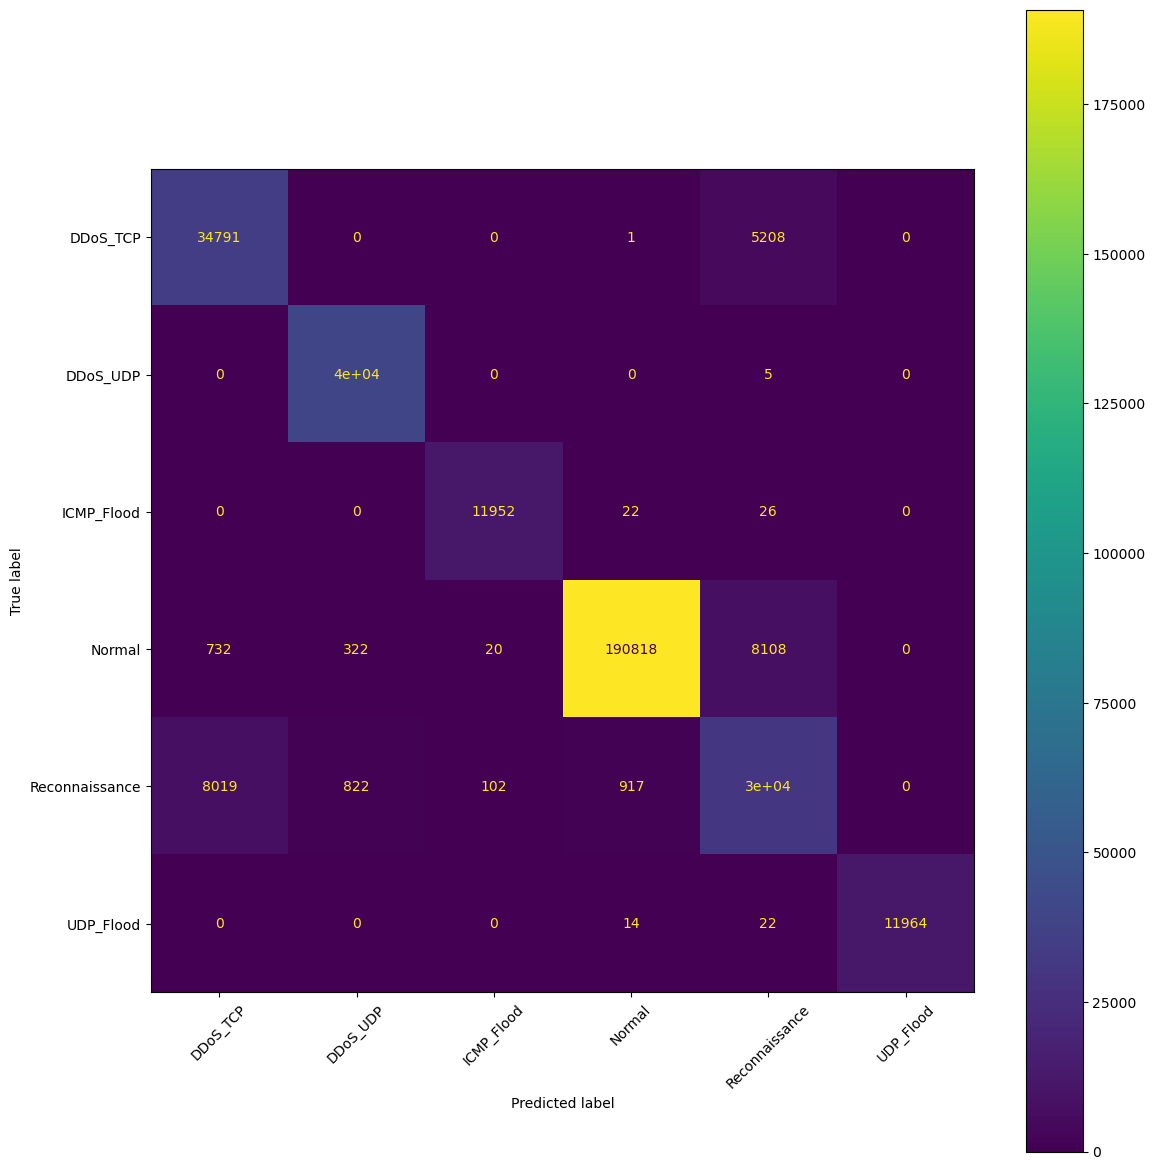

In [79]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

la_matriz = [
    'DDoS_TCP',
    'DDoS_UDP',
    'ICMP_Flood',
    'Normal',
    'Reconnaissance',
    'UDP_Flood'
]

cm = confusion_matrix(
    df1['tipo_ataque'],
    df1['Trans_cluster'],
    labels=la_matriz
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=la_matriz
)

fig, ax = plt.subplots(figsize=(12, 12))
disp.plot(ax=ax, xticks_rotation=45)
plt.tight_layout()
plt.show()

In [82]:
pd.options.display.max_rows = 1000
pd.options.display.max_columns = 1200 

# Explicabilidad Kmeans

In [83]:
# Produce the SHAP values kmeans
kmeans_explainer = shap.KernelExplainer(model_.predict,X_Test.sample(500))

Using 500 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


In [84]:
kmeans_shap_values = kmeans_explainer.shap_values(X_Test.sample(500))

  0%|          | 0/500 [00:00<?, ?it/s]

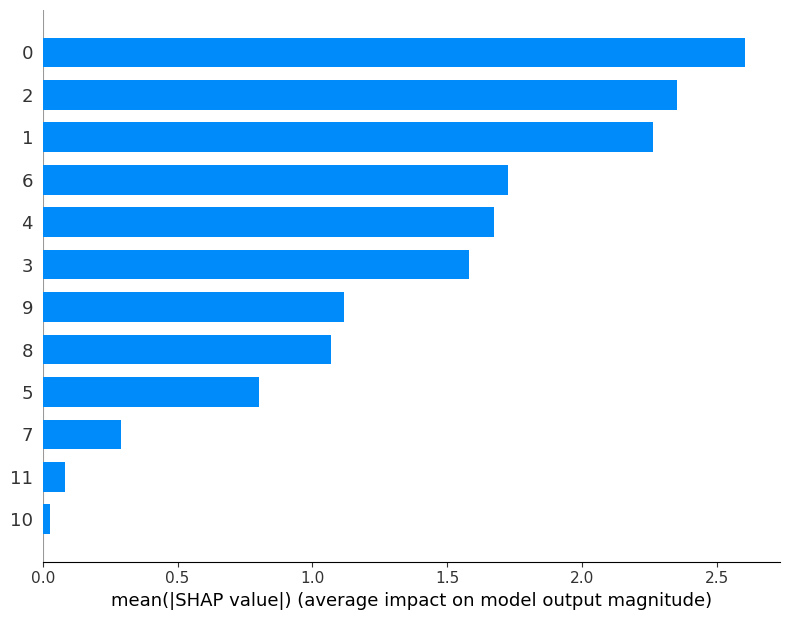

In [85]:
# Primera forma de visualizar los SHAP values kMeans
shap.summary_plot(kmeans_shap_values, X_Test, plot_type='bar')

In [86]:
pd.DataFrame(kmeans_shap_values, columns=X_Train.columns)[0].abs().mean()

np.float64(2.6033309279800276)

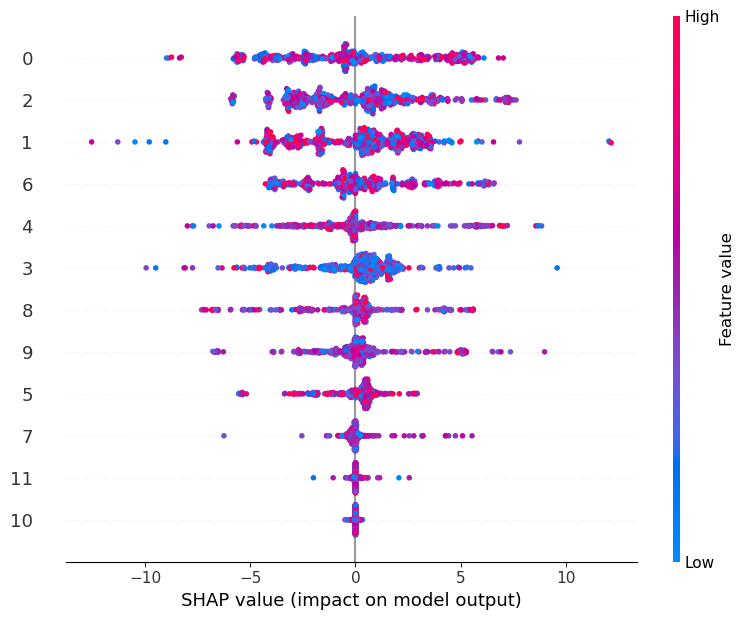

In [89]:
#Segunda Forma de Calcular los SHAP values Kmeans
shap.summary_plot(kmeans_shap_values, X_Test.sample(500))

In [ ]:
# # organizacion excel
# pp1_ = pd.concat([pp1,df['protocols'],df1[['label','tipo_ataque','Trans_cluster','cluster']]],axis=1)
# pp1_

In [ ]:
# pp1_ = pd.concat([pp1,df['protocols'],df1[['label','tipo_ataque','Trans_cluster','cluster']]],axis=1)

# d=['min','max','count']
# ata=la_matriz[0]

# c_olumn =['number__delta_time', 'number__port_src', 'number__port_dst', 'number__frame_len', 'number__udp_len', 'number__ip_ttl',
#           'number__tos', 'number__ip_flags_df', 'number__ip_flags_mf', 'number__tcp_flags_ns', 'number__tcp_flags_syn',
#           'category__protocols','Trans_cluster','cluster','tipo_ataque','label','protocols']
# a0=pp1_[['number__delta_time', 'number__port_src', 'number__port_dst', 'number__frame_len', 'number__udp_len', 'number__ip_ttl',
#          'number__tos', 'number__ip_flags_df', 'number__ip_flags_mf', 'number__tcp_flags_ns', 'number__tcp_flags_syn',
#          'category__protocols','Trans_cluster','cluster','tipo_ataque','label','protocols']][pp1_['Trans_cluster']==ata].groupby(['cluster','tipo_ataque']).agg({ i:{'min','max','count'} for i in c_olumn}).T
# b0=pp1_[['number__delta_time', 'number__port_src', 'number__port_dst', 'number__frame_len', 'number__udp_len', 'number__ip_ttl',
#          'number__tos', 'number__ip_flags_df', 'number__ip_flags_mf', 'number__tcp_flags_ns', 'number__tcp_flags_syn',
#          'category__protocols','Trans_cluster','cluster','tipo_ataque','label','protocols']].groupby(['tipo_ataque']).agg({ i:d for i in c_olumn}).T
# pd.concat([b0.loc[:,ata],a0,],axis=1)

In [ ]:
# pp1_[pp1_['cluster']==5]['category__protocols'].value_counts()

# DBscan

In [38]:
from numpy import unique
from numpy import where
from sklearn.datasets import make_classification
from sklearn.cluster import DBSCAN
from matplotlib import pyplot
dbscan_1 = Pipeline(steps=[('preprocessor_3_pca',preprocessor_3),
                           ('dbscan',DBSCAN(eps=eps, min_samples= m_samples))])

In [39]:
dbscan_1.fit(X)

Pipeline(steps=[('preprocessor_3_pca',
                 Pipeline(steps=[('prepro_2_del',
                                  Pipeline(steps=[('prepro_1_num_cat',
                                                   ColumnTransformer(transformers=[('number',
                                                                                    Pipeline(steps=[('impute',
                                                                                                     SimpleImputer(fill_value=-1,
                                                                                                                   strategy='constant'))]),
                                                                                    ['delta_time',
                                                                                     'port_src',
                                                                                     'port_dst',
                                                                                     'frame_len',
                                                                                     'udp_len',
                                                                                     'ip_ttl',
                                                                                     'icmp_type',
                                                                                     'tos',
                                                                                     'ip_flags_rb',
                                                                                     'ip_flags_df',
                                                                                     'ip_flags_m...
                                                                        'number__tcp_flags_res',
                                                                        'number__tcp_flags_ns',
                                                                        'number__tcp_flags_cwr',
                                                                        'number__tcp_flags_ecn',
                                                                        'number__tcp_flags_urg',
                                                                        'number__tcp_flags_ack',
                                                                        'number__tcp_flags_push',
                                                                        'number__tcp_flags_reset',
                                                                        'number__tcp_flags_syn',
                                                                        'number__tcp_flags_fin']))])),
                                 ('scaler', StandardScaler()),
                                 ('pca', PCA(n_components=6))])),
                ('dbscan', DBSCAN(eps=0.01924652961188758, min_samples=29))])

In [40]:
df2.columns

NameError: name 'df2' is not defined

In [41]:
pip show scikit-learn

Name: scikit-learn
Version: 1.6.1
Summary: A set of python modules for machine learning and data mining
Home-page: 
Author: 
Author-email: 
License: BSD 3-Clause License

 Copyright (c) 2007-2024 The scikit-learn developers.
 All rights reserved.

 Redistribution and use in source and binary forms, with or without
 modification, are permitted provided that the following conditions are met:

 * Redistributions of source code must retain the above copyright notice, this
   list of conditions and the following disclaimer.

 * Redistributions in binary form must reproduce the above copyright notice,
   this list of conditions and the following disclaimer in the documentation
   and/or other materials provided with the distribution.

 * Neither the name of the copyright holder nor the names of its
   contributors may be used to endorse or promote products derived from
   this software without specific prior written permission.

 THIS SOFTWARE IS PROVIDED BY THE COPYRIGHT HOLDERS AND CONTRIB

In [42]:
predictions_2 = dbscan_1.fit_predict(X)

In [214]:
# con duplicados
predictions_2 = dbscan_1.fit_predict(X)
df2=pp1.copy()

predictions_2 = dbscan_1.fit_predict(X)
df2=pp1.copy()

# metricas por tipo de ataque
df2['predict'] =pd.DataFrame(predictions_2, index=X.index)
df2[['label','tipo_ataque']] = df[['label','tipo_ataque']].copy()
df2.head(5)
metricas.y(df2, -1,max(df2['predict']+1))
metricas.metricas(df2)
metricas.metrica_internas(pp3,df2['predict'])
matriz=metricas. matriz(df2)
sh,chs,dbs=metricas.metrica_internas(pp3,df2['predict'])
print(f'Silhouette: {sh}')
print(f'Calinski: {chs}')
print(f'Davies: {dbs}')
print(matriz[0])
print(matriz[1])
max(df2['predict'])

print('Rendimiento de Gastos Generales:')
print(f"tiempo:--- {time.time() - start_time} Segundos ---")
print('tiempo_cpu', t_cpu)
print('%_cpu', '%.2f%%' % cpu_usage)
print('%_mem', '%.2f%%' % mem_usage)
print ('consumo de disco', '%.2f%%' % disco2[3])

-1 Normal
0 Normal
1 DDoS_TCP
2 Normal
3 Normal
4 Normal
5 Normal
6 Normal
7 Normal
8 Normal
9 Normal
10 Normal
11 Normal
12 Normal
13 Normal
14 Normal
15 Normal
16 Normal
17 Normal
18 Reconnaissance_Service_Scan
19 Normal
20 Normal
21 Normal
22 Normal
23 Normal
24 Normal
25 Normal
26 Reconnaissance_Service_Scan
27 Normal
28 Normal
29 Normal
30 Normal
31 Normal
32 Normal
33 Normal
34 Normal
35 DoS_UDP
36 Normal
37 Normal
38 Normal
39 Normal
40 Normal
41 Normal
42 Normal
43 Normal
44 Normal
45 Reconnaissance_Service_Scan
46 Normal
47 Normal
48 Normal
49 Normal
50 Normal
51 Normal
52 Normal
53 Normal
54 Normal
55 Normal
56 Normal
57 Reconnaissance_OS_Fingerprint
58 Normal
59 Normal
60 Normal
61 Normal
62 Normal
63 Normal
64 Reconnaissance_Service_Scan
65 Normal
66 Normal
67 Normal
68 Normal
69 Normal
70 Normal
71 Normal
72 Normal
73 Normal
74 Normal
75 DoS_TCP
76 Normal
77 Normal
78 Reconnaissance_OS_Fingerprint
79 Normal
80 Normal
81 Normal
82 Normal
83 Normal
84 Normal
85 Normal
86 Nor

In [108]:
matriz[1]

,tp,fp,fn,tn,tp+fn,tp+fp,fn+tn,fp+tn,recall,precision,F1
tipo_ataque,,,,,,,,,,,
Normal,197362,29304,2638,70696.0,200000,226666,73334.0,100000.0,0.98681,0.870717,0.925136
Reconnaissance_Service_Scan,5919,3155,14081,276845,20000,9074,290926,280000,0.29595,0.652303,0.407168
DDoS_TCP,19904,10742,96,269258,20000,30646,269354,280000,0.9952,0.649481,0.786005
DoS_TCP,9157,0,10843,280000,20000,9157,290843,280000,0.45785,1.0,0.628117
Reconnaissance_OS_Fingerprint,3163,1392,16837,278608,20000,4555,295445,280000,0.15815,0.694402,0.257626
DoS_UDP,19902,0,98,280000.0,20000,19902,280098.0,280000.0,0.9951,1.0,0.997544


In [111]:
df2.columns

Index(['number__delta_time', 'number__port_src', 'number__port_dst',
       'number__frame_len', 'number__udp_len', 'number__ip_ttl', 'number__tos',
       'number__ip_flags_df', 'number__ip_flags_mf', 'number__tcp_flags_ns',
       'number__tcp_flags_syn', 'predict', 'label', 'tipo_ataque',
       'Trans_predict'],
      dtype='object')

In [113]:
df2['Trans_predict'].value_counts()

Trans_predict
Normal                           226666
DDoS_TCP                          30646
DoS_UDP                           19902
DoS_TCP                            9157
Reconnaissance_Service_Scan        9074
Reconnaissance_OS_Fingerprint      4555
Name: count, dtype: int64

In [115]:
df2['tipo_ataque'].value_counts()

tipo_ataque
Normal                           200000
Reconnaissance_Service_Scan       20000
DDoS_TCP                          20000
DoS_TCP                           20000
Reconnaissance_OS_Fingerprint     20000
DoS_UDP                           20000
Name: count, dtype: int64

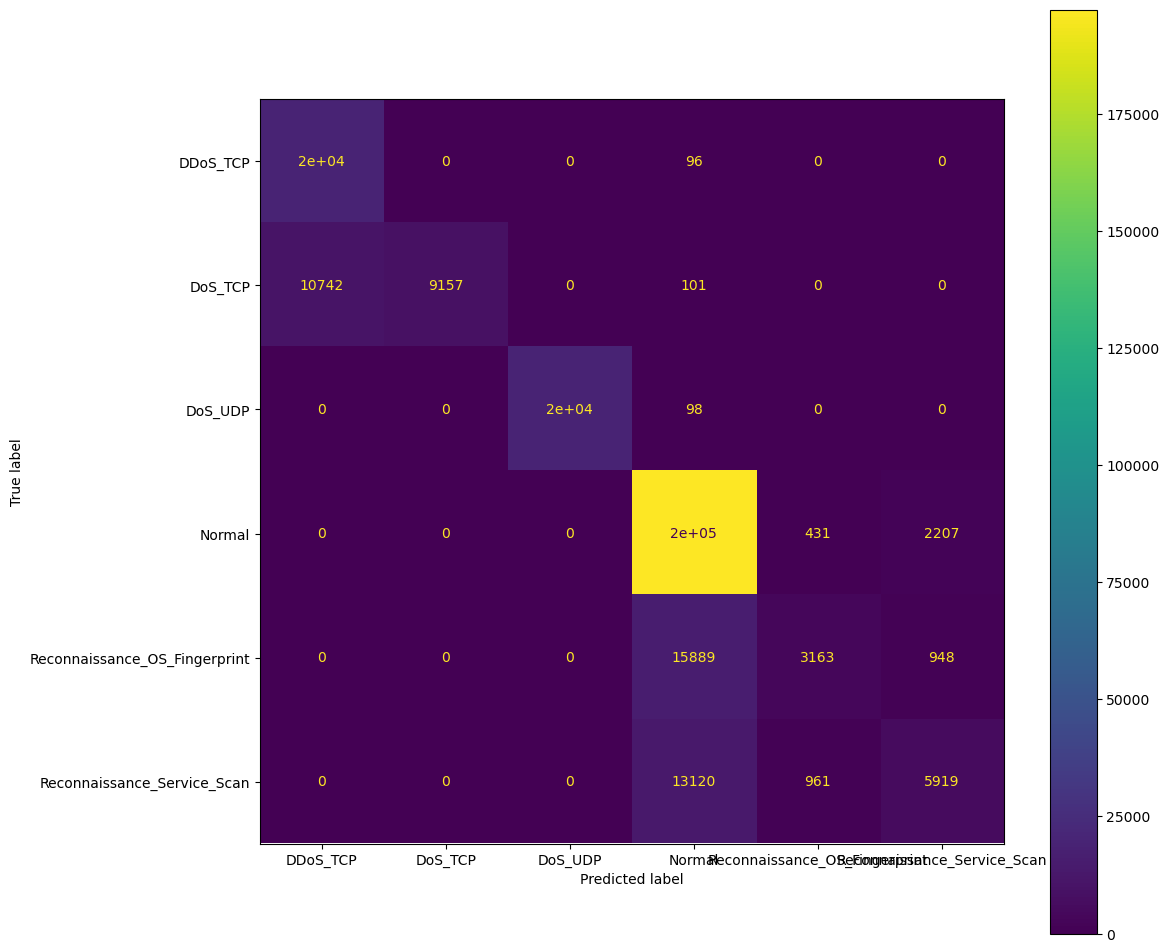

In [116]:
# metricas por tipo de ataque
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
la_matriz=['DDoS_TCP','DoS_TCP','DoS_UDP','Normal','Reconnaissance_OS_Fingerprint','Reconnaissance_Service_Scan']
cm=confusion_matrix(df2['tipo_ataque'], df2['Trans_predict'])
disp = ConfusionMatrixDisplay(cm,display_labels=la_matriz)
fig, ax = plt.subplots(figsize=(12,12))
disp.plot(ax=ax)

In [118]:
# disminucion de ataques de tipos de ataque a categorias
old_keys=['tipo_ataque', 'Trans_predict']
new_keys=['tipo_ataque','Trans_predict']

new_categories(df2,old_keys,new_keys)

tipo_ataque
Normal            200000
Reconnaissance     40000
DDoS_TCP           40000
DDoS_UDP           20000
Name: count, dtype: int64
Trans_predict
Normal            226666
DDoS_TCP           39803
DDoS_UDP           19902
Reconnaissance     13629
Name: count, dtype: int64


In [70]:
pp3

,0,1,2,3,4,5
10340,-3.358061,-0.496553,-0.031544,-0.695944,0.316734,-0.648238
208905,1.020481,-4.370952,-1.238257,2.617493,-4.581752,-2.998889
299463,2.703061,0.111313,1.135163,-0.425851,-0.140212,-0.240964
132215,-0.700718,1.527335,0.246689,-0.130277,-0.248283,-0.785916
151597,-2.956058,-0.564629,-0.000887,-0.568674,0.271483,-0.404974
...,...,...,...,...,...,...
196149,-0.307589,1.296184,0.288755,-0.089093,-0.247447,-0.556962
123714,-1.893255,-0.744545,0.080115,-0.232098,0.151824,0.238268
263138,2.195142,0.343523,0.980462,-0.330504,-0.084380,-0.223172
194602,-2.136758,-0.724265,-0.156200,-0.278743,0.234809,0.030561


In [119]:
# metricas por categoria
metricas.metricas(df2)
sh,chs,dbs=metricas.metrica_internas(pp3,df2['predict'])
print(f'Silhouette: {sh}')
print(f'Calinski: {chs}')
print(f'Davies: {dbs}')
matriz=metricas.matriz(df2)
print(matriz[0])
print(matriz[1])
# print(matriz[1])
max(df2['predict'])


#otras metricas
import psutil
import GPUtil
import matplotlib.pyplot as plt

print('Rendimiento de Gastos Generales:')
print(f"tiempo:--- {time.time() - start_time} Segundos ---")
print('tiempo_cpu', t_cpu)
print('%_cpu', '%.2f%%' % cpu_usage)
print('%_mem', '%.2f%%' % mem_usage)
print ('consumo de disco', '%.2f%%' % disco2[3])

                precision    recall  f1-score   support

      DDoS_TCP       1.00      1.00      1.00     40000
      DDoS_UDP       1.00      1.00      1.00     20000
        Normal       0.87      0.99      0.93    200000
Reconnaissance       0.81      0.27      0.41     40000

      accuracy                           0.89    300000
     macro avg       0.92      0.81      0.83    300000
  weighted avg       0.89      0.89      0.87    300000

Purity  0.89353
homogeneity_score:  0.67682
completeness_score:  0.8358
v_measure_score:  0.74795
adjusted_mutual_info_score:  0.74795
Silhouette: 0.49645
Calinski: 3306.49346
Davies: 1.06399

Normal
         Positive Negative
Positive   197362     2638
Negative    29304  70696.0

Reconnaissance
         Positive Negative
Positive    10991    29009
Negative     2638   257362

DDoS_TCP
         Positive Negative
Positive    39803      197
Negative        0   260000

DDoS_UDP
         Positive  Negative
Positive    19902        98
Negative      

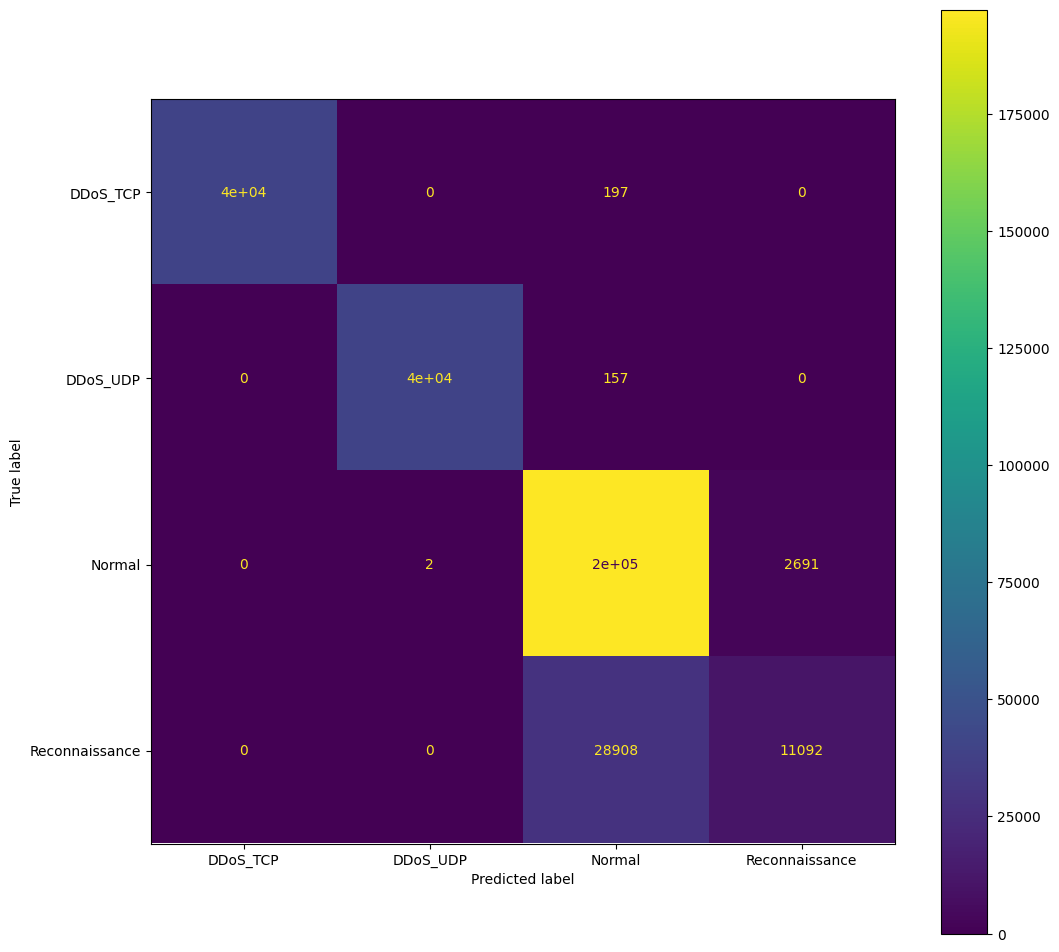

In [72]:
# metricas por tipo de ataque
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
la_matriz=['DDoS_TCP','DDoS_UDP','Normal','Reconnaissance']
cm=confusion_matrix(df2['categoria'], df2[ 'Trans_cluster_'])
disp = ConfusionMatrixDisplay(cm,display_labels=la_matriz)
fig, ax = plt.subplots(figsize=(12,12))
disp.plot(ax=ax)

In [121]:
df2.columns

Index(['number__delta_time', 'number__port_src', 'number__port_dst',
       'number__frame_len', 'number__udp_len', 'number__ip_ttl', 'number__tos',
       'number__ip_flags_df', 'number__ip_flags_mf', 'number__tcp_flags_ns',
       'number__tcp_flags_syn', 'predict', 'label', 'tipo_ataque',
       'Trans_predict', 'categoria'],
      dtype='object')

In [215]:
# guarda lista para aplicacion
import importlib
importlib.reload(metricas)
l=metricas.y(df2.drop(['Trans_predict'],axis=1),-1, max(df2['predict']+1))
with open('list_dbscan2_over.txt','w') as f:
    f.write(str(l))

-1 Normal
0 Normal
1 DDoS_TCP
2 Normal
3 Normal
4 Normal
5 Normal
6 Normal
7 Normal
8 Normal
9 Normal
10 Normal
11 Normal
12 Normal
13 Normal
14 Normal
15 Normal
16 Normal
17 Normal
18 Reconnaissance_Service_Scan
19 Normal
20 Normal
21 Normal
22 Normal
23 Normal
24 Normal
25 Normal
26 Reconnaissance_Service_Scan
27 Normal
28 Normal
29 Normal
30 Normal
31 Normal
32 Normal
33 Normal
34 Normal
35 DoS_UDP
36 Normal
37 Normal
38 Normal
39 Normal
40 Normal
41 Normal
42 Normal
43 Normal
44 Normal
45 Reconnaissance_Service_Scan
46 Normal
47 Normal
48 Normal
49 Normal
50 Normal
51 Normal
52 Normal
53 Normal
54 Normal
55 Normal
56 Normal
57 Reconnaissance_OS_Fingerprint
58 Normal
59 Normal
60 Normal
61 Normal
62 Normal
63 Normal
64 Reconnaissance_Service_Scan
65 Normal
66 Normal
67 Normal
68 Normal
69 Normal
70 Normal
71 Normal
72 Normal
73 Normal
74 Normal
75 DoS_TCP
76 Normal
77 Normal
78 Reconnaissance_OS_Fingerprint
79 Normal
80 Normal
81 Normal
82 Normal
83 Normal
84 Normal
85 Normal
86 Nor

In [43]:
print('= = ='*10,'12. Guardar el Modelo KMeans ')
pickle_model('dbscan_1_6_1_EJERCICIO10_n_components6_fit_over.pkl', 'wb', dbscan_1)

= = == = == = == = == = == = == = == = == = == = = 12. Guardar el Modelo KMeans 
Modelo dbscan_1_6_1_EJERCICIO10_n_components6_fit_over.pkl guardado.


In [75]:
#23/11
#'list_dbscan2.txt' 'list_dbscan2.txt'
#dbscan_EJERCICIO10_.csv 

# df2.to_csv('dbscan_EJERCICIO10_.csv')

# Local outlier factor

In [45]:
from numpy import unique
from numpy import where
from sklearn.datasets import make_classification
from sklearn.neighbors import LocalOutlierFactor
from matplotlib import pyplot
lof_1 = Pipeline(steps=[('preprocessor_3_pca',preprocessor_3),
                           ('lof',LocalOutlierFactor(novelty=True,n_neighbors=20, metric='minkowski', contamination=0.05))])
lof_1

Pipeline(steps=[('preprocessor_3_pca',
                 Pipeline(steps=[('prepro_2_del',
                                  Pipeline(steps=[('prepro_1_num_cat',
                                                   ColumnTransformer(transformers=[('number',
                                                                                    Pipeline(steps=[('impute',
                                                                                                     SimpleImputer(fill_value=-1,
                                                                                                                   strategy='constant'))]),
                                                                                    ['delta_time',
                                                                                     'port_src',
                                                                                     'port_dst',
                                                                                     'frame_len',
                                                                                     'udp_len',
                                                                                     'ip_ttl',
                                                                                     'icmp_type',
                                                                                     'tos',
                                                                                     'ip_flags_rb',
                                                                                     'ip_flags_df',
                                                                                     'ip_flags_m...
                                                                        'number__tcp_flags_res',
                                                                        'number__tcp_flags_ns',
                                                                        'number__tcp_flags_cwr',
                                                                        'number__tcp_flags_ecn',
                                                                        'number__tcp_flags_urg',
                                                                        'number__tcp_flags_ack',
                                                                        'number__tcp_flags_push',
                                                                        'number__tcp_flags_reset',
                                                                        'number__tcp_flags_syn',
                                                                        'number__tcp_flags_fin']))])),
                                 ('scaler', StandardScaler()),
                                 ('pca', PCA(n_components=6))])),
                ('lof', LocalOutlierFactor(contamination=0.05, novelty=True))])

In [24]:
ind_train = df.loc[df['tipo_ataque'] == 'Normal'].index
cantidad = len(ind_train)*0.6
ind_train = ind_train[:int(cantidad)]

#print(cantidad)
X_train= df.loc[df['tipo_ataque'] == 'Normal'].head(int(cantidad)).drop(['label','tipo_ataque'],axis=1)
print(X_train.tail(5))
y_train = df.loc[df['tipo_ataque'] == 'Normal'].head(int(cantidad))['label']
print(y_train)

        delta_time protocols  port_src  port_dst  frame_len  udp_len  ip_ttl  \
53137     0.000020       UDP    3456.0      80.0       1020    986.0   127.0   
150074    0.000001       TCP      80.0      80.0       1160      NaN   127.0   
189084    0.000010       TCP    8080.0      80.0        907      NaN   127.0   
17104     0.057843       TCP      80.0    8080.0        754      NaN   127.0   
57723     0.000005       TCP    8080.0      80.0       1335      NaN   127.0   

        icmp_type  tos  ip_flags_rb  ...  tcp_flags_res  tcp_flags_ns  \
53137         NaN  0.0          0.0  ...            NaN           NaN   
150074        NaN  0.0          0.0  ...            0.0           0.0   
189084        NaN  0.0          0.0  ...            0.0           0.0   
17104         NaN  0.0          0.0  ...            0.0           0.0   
57723         NaN  0.0          0.0  ...            0.0           0.0   

        tcp_flags_cwr  tcp_flags_ecn  tcp_flags_urg  tcp_flags_ack  \
53137     

In [25]:
last_ind = ind_train[-1]
copy = df.loc[df['tipo_ataque'] == 'Normal'].loc[last_ind:].drop([last_ind],axis=0).index
ind_test = df.loc[df['tipo_ataque'] != 'Normal'].index
ind_test =ind_test.append(copy)
X_test = df.iloc[df.index.get_indexer(ind_test.difference(ind_train, sort=False))].drop(['label','tipo_ataque'],axis=1)
print(X_test.head(5))
y_test = df.iloc[df.index.get_indexer(ind_test.difference(ind_train, sort=False))]['label']
print(y_test.head(5))

        delta_time protocols  port_src  port_dst  frame_len  udp_len  ip_ttl  \
254986    0.000000       UDP    3007.0      80.0         60      8.0    64.0   
209653    0.006741       UDP   36529.0   40711.0         60      8.0    57.0   
220304    0.000000       TCP   46997.0    3869.0         60      NaN    43.0   
241429    0.000001       UDP    4302.0      80.0         60      8.0    64.0   
278615    0.000002       TCP   44880.0      80.0        154      NaN    64.0   

        icmp_type  tos  ip_flags_rb  ...  tcp_flags_res  tcp_flags_ns  \
254986        NaN  0.0          0.0  ...            NaN           NaN   
209653        NaN  0.0          0.0  ...            NaN           NaN   
220304        NaN  0.0          0.0  ...            0.0           0.0   
241429        NaN  0.0          0.0  ...            NaN           NaN   
278615        NaN  0.0          0.0  ...            0.0           0.0   

        tcp_flags_cwr  tcp_flags_ecn  tcp_flags_urg  tcp_flags_ack  \
254986    

In [48]:
model_ = LocalOutlierFactor(n_neighbors=20, metric='minkowski', contamination=0.05)
y_pred_lof = model_.fit_predict(X_Test)
y_pred_lof = np.array([1 if x == -1 else 0 for x in y_pred_lof])

In [49]:
model = lof_1.fit(X_train)
model

Pipeline(steps=[('preprocessor_3_pca',
                 Pipeline(steps=[('prepro_2_del',
                                  Pipeline(steps=[('prepro_1_num_cat',
                                                   ColumnTransformer(transformers=[('number',
                                                                                    Pipeline(steps=[('impute',
                                                                                                     SimpleImputer(fill_value=-1,
                                                                                                                   strategy='constant'))]),
                                                                                    ['delta_time',
                                                                                     'port_src',
                                                                                     'port_dst',
                                                                                     'frame_len',
                                                                                     'udp_len',
                                                                                     'ip_ttl',
                                                                                     'icmp_type',
                                                                                     'tos',
                                                                                     'ip_flags_rb',
                                                                                     'ip_flags_df',
                                                                                     'ip_flags_m...
                                                                        'number__tcp_flags_res',
                                                                        'number__tcp_flags_ns',
                                                                        'number__tcp_flags_cwr',
                                                                        'number__tcp_flags_ecn',
                                                                        'number__tcp_flags_urg',
                                                                        'number__tcp_flags_ack',
                                                                        'number__tcp_flags_push',
                                                                        'number__tcp_flags_reset',
                                                                        'number__tcp_flags_syn',
                                                                        'number__tcp_flags_fin']))])),
                                 ('scaler', StandardScaler()),
                                 ('pca', PCA(n_components=6))])),
                ('lof', LocalOutlierFactor(contamination=0.05, novelty=True))])

In [50]:
test_scores = lof_1.predict(X_test)
print(test_scores)
# Predict the labels (1 inlier, -1 outlier) of X according to LOF.
n_error_outliers = test_scores[test_scores == -1].size
n_error_test = test_scores[test_scores == 1].size
print(f'n_error_test {n_error_test}')
print(f'n_error_outliers {n_error_outliers}')

[-1 -1 -1 ...  1  1  1]
n_error_test 119560
n_error_outliers 60440


In [131]:
# NOTA
y_test.value_counts()

label
1    100000
0     80000
Name: count, dtype: int64

In [132]:
X_test['Trans_predict'] = test_scores
X_test

,delta_time,protocols,port_src,port_dst,frame_len,udp_len,ip_ttl,icmp_type,tos,ip_flags_rb,...,tcp_flags_ns,tcp_flags_cwr,tcp_flags_ecn,tcp_flags_urg,tcp_flags_ack,tcp_flags_push,tcp_flags_reset,tcp_flags_syn,tcp_flags_fin,Trans_predict
213717,0.029318,UDP,38760.0,18994.0,60,8.0,51.0,NaN,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
266423,0.000001,TCP,32927.0,80.0,154,NaN,64.0,NaN,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,-1
286016,0.000002,TCP,54949.0,80.0,154,NaN,64.0,NaN,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,-1
236762,0.000000,TCP,55499.0,4279.0,60,NaN,49.0,NaN,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,-1
276218,0.000002,TCP,48341.0,80.0,154,NaN,64.0,NaN,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,-1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
80218,0.000003,TCP,80.0,80.0,761,NaN,127.0,NaN,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
124599,0.000001,UDP,80.0,80.0,1445,1411.0,127.0,NaN,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
9454,0.057808,TCP,80.0,8080.0,1259,NaN,127.0,NaN,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
27857,0.003531,UDP,80.0,80.0,1498,1464.0,127.0,NaN,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1


LOF con novelty= True, tiene las desventaja en este dataset debido a que existen al paquetes normales que se parence ataques

In [133]:
X_test['Trans_predict'] = X_test['Trans_predict'].mask(X_test['Trans_predict'] == 1,0)
X_test['Trans_predict'] = X_test['Trans_predict'].mask(X_test['Trans_predict'] == -1,1)
X_test['Trans_predict']

213717    0
266423    1
286016    1
236762    1
276218    1
         ..
80218     0
124599    0
9454      0
27857     0
139768    0
Name: Trans_predict, Length: 180000, dtype: int64

In [134]:
pp1_=preprocessor_2.fit_transform(X_test)
pp1_.index = X_test.index
pp1_

,number__delta_time,number__port_src,number__port_dst,number__frame_len,number__udp_len,number__ip_ttl,number__tos,number__ip_flags_df,number__ip_flags_mf,number__tcp_flags_ns,number__tcp_flags_syn
213717,0.029318,38760.0,18994.0,60.0,8.0,51.0,0.0,0.0,0.0,-1.0,-1.0
266423,0.000001,32927.0,80.0,154.0,-1.0,64.0,0.0,0.0,0.0,0.0,1.0
286016,0.000002,54949.0,80.0,154.0,-1.0,64.0,0.0,0.0,0.0,0.0,1.0
236762,0.000000,55499.0,4279.0,60.0,-1.0,49.0,0.0,0.0,0.0,0.0,1.0
276218,0.000002,48341.0,80.0,154.0,-1.0,64.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...
80218,0.000003,80.0,80.0,761.0,-1.0,127.0,0.0,0.0,0.0,0.0,0.0
124599,0.000001,80.0,80.0,1445.0,1411.0,127.0,0.0,0.0,0.0,-1.0,-1.0
9454,0.057808,80.0,8080.0,1259.0,-1.0,127.0,0.0,0.0,0.0,0.0,0.0
27857,0.003531,80.0,80.0,1498.0,1464.0,127.0,0.0,0.0,0.0,-1.0,-1.0


In [135]:
X_ = pd.concat([pp1_,X_test['Trans_predict'],y_test],axis=1)
X_

,number__delta_time,number__port_src,number__port_dst,number__frame_len,number__udp_len,number__ip_ttl,number__tos,number__ip_flags_df,number__ip_flags_mf,number__tcp_flags_ns,number__tcp_flags_syn,Trans_predict,label
213717,0.029318,38760.0,18994.0,60.0,8.0,51.0,0.0,0.0,0.0,-1.0,-1.0,0,1
266423,0.000001,32927.0,80.0,154.0,-1.0,64.0,0.0,0.0,0.0,0.0,1.0,1,1
286016,0.000002,54949.0,80.0,154.0,-1.0,64.0,0.0,0.0,0.0,0.0,1.0,1,1
236762,0.000000,55499.0,4279.0,60.0,-1.0,49.0,0.0,0.0,0.0,0.0,1.0,1,1
276218,0.000002,48341.0,80.0,154.0,-1.0,64.0,0.0,0.0,0.0,0.0,1.0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
80218,0.000003,80.0,80.0,761.0,-1.0,127.0,0.0,0.0,0.0,0.0,0.0,0,0
124599,0.000001,80.0,80.0,1445.0,1411.0,127.0,0.0,0.0,0.0,-1.0,-1.0,0,0
9454,0.057808,80.0,8080.0,1259.0,-1.0,127.0,0.0,0.0,0.0,0.0,0.0,0,0
27857,0.003531,80.0,80.0,1498.0,1464.0,127.0,0.0,0.0,0.0,-1.0,-1.0,0,0


In [136]:
X_=X_.rename(columns={'label':'tipo_ataque'})

In [138]:
metricas.metricas(X_)

print('Rendimiento de Gastos Generales:')
print(f"tiempo:--- {time.time() - start_time} Segundos ---")
print('tiempo_cpu', t_cpu)
print('%_cpu', '%.2f%%' % cpu_usage)
print('%_mem', '%.2f%%' % mem_usage)
print ('consumo de disco', '%.2f%%' % disco2[3])

              precision    recall  f1-score   support

           0       0.67      0.95      0.78     80000
           1       0.94      0.62      0.75    100000

    accuracy                           0.77    180000
   macro avg       0.80      0.79      0.77    180000
weighted avg       0.82      0.77      0.76    180000

Purity  0.76799
homogeneity_score:  0.29133
completeness_score:  0.30376
v_measure_score:  0.29742
adjusted_mutual_info_score:  0.29741
Rendimiento de Gastos Generales:
tiempo:--- 84623.98857593536 Segundos ---
tiempo_cpu scputimes(user=5039.1, nice=1.58, system=2639.77, idle=115155.99, iowait=29.32, irq=0.0, softirq=19.88, steal=1.3, guest=0.0, guest_nice=0.0)
%_cpu 7.60%
%_mem 2.80%
consumo de disco 12.30%


In [53]:
matriz1=metricas.matriz(X_)
matriz1[0]


1
         Positive Negative
Positive    67810    32190
Negative     4383  75617.0

0
         Positive Negative
Positive    75617     4383
Negative    32190  67810.0


,Cantidad,coincidencia,% prediccion,total prediciones
0,100000,67810,0.6781,72193
1,80000.0,75617.0,0.945213,107807.0


In [55]:
matriz1[1]

,tp,fp,fn,tn,tp+fn,tp+fp,fn+tn,fp+tn,recall,precision,F1
tipo_ataque,,,,,,,,,,,
1,67810,4383,32190,75617.0,100000,72193,107807.0,80000.0,0.6781,0.939288,0.787605
0,75617,32190,4383,67810.0,80000,107807,72193.0,100000.0,0.945213,0.701411,0.805263


In [57]:
# datos para realizar las metricas internas
preprocessor_3.fit(X_test)
pp3 = preprocessor_3.transform(X_test)
# #Con PCA
pp3 = pd.DataFrame(pp3, index=X_test.index)
# #Sin PCA
# pp3 = pd.DataFrame(pp3, index=X.index,columns=pp1.columns)
pp3

,0,1,2,3,4,5
202849,2.216673,-0.124734,-0.210007,0.094061,-0.019473,0.177011
253279,-0.358790,1.209752,-0.963679,0.021950,-0.045499,-1.282837
289704,1.589198,-0.658506,-0.479332,0.113279,0.102096,0.102809
290475,1.593236,-0.657721,-0.480466,0.113975,0.102439,0.103571
237020,2.361214,-0.344230,-0.683759,0.167387,0.095579,0.031486
...,...,...,...,...,...,...
53532,0.746786,3.376331,3.126556,-2.443598,-0.113092,-1.841543
184308,-3.715116,0.034663,-0.451961,0.909478,-0.467615,0.537833
7501,-3.802291,0.132450,-0.273047,0.887070,-0.532544,0.594356
72123,0.237973,1.311260,-0.254085,-1.152514,0.412081,-2.085702


In [58]:
sh,chs,dbs=metricas.metrica_internas(pp3,X_['Trans_predict'])
print(f'Calinski: {sh}')
print(f'Calinski: {chs}')
print(f'Davies: {dbs}')

print('Rendimiento de Gastos Generales:')
print(f"tiempo:--- {time.time() - start_time} Segundos ---")
print('tiempo_cpu', t_cpu)
print('%_cpu', '%.2f%%' % cpu_usage)
print('%_mem', '%.2f%%' % mem_usage)
print ('consumo de disco', '%.2f%%' % disco2[3])

Calinski: 0.13328
Calinski: 18444.34536
Davies: 2.36762
Rendimiento de Gastos Generales:
tiempo:--- 471.18253445625305 Segundos ---
tiempo_cpu scputimes(user=530.2, nice=7.81, system=266.68, idle=44291.45, iowait=30.12, irq=0.0, softirq=24.99, steal=0.0, guest=0.0, guest_nice=0.0)
%_cpu 6.50%
%_mem 26.70%
consumo de disco 89.40%


## Probar con Ton-IoT

In [100]:
dataT=pd.read_csv("Conjunto de Datos Ton IoT/Conjuntos de Datos Finalizados/data_completa_final.csv")

In [101]:
dataT=dataT.rename(columns={'tcp_srcport':'port_src','tcp_dstport':'port_dst','udp_length':'udp_len'})
dataT

,Unnamed: 0.1,Unnamed: 0,delta_time,protocols,ip_src,ip_dst,port_src,port_dst,frame_len,udp_len,...,tcp_flags_ecn,tcp_flags_urg,tcp_flags_ack,tcp_flags_push,tcp_flags_reset,tcp_flags_syn,tcp_flags_fin,frame_time_epoch,ataque,ataque_binario
0,0,77690,0.000149,TCP,192.168.1.31,52.59.177.21,38842.0,8080.0,68,NaN,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.556205e+09,DDOS,1
1,1,45234,0.006621,0xc0a8,NaN,NaN,NaN,NaN,181,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.554225e+09,Normal,0
2,2,30014,0.006668,0xc0a8,NaN,NaN,NaN,NaN,634,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.554222e+09,Normal,0
3,3,41947,0.006677,0xc0a8,NaN,NaN,NaN,NaN,345,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.554227e+09,Normal,0
4,4,8311,0.006668,0xc0a8,NaN,NaN,NaN,NaN,852,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.554225e+09,Normal,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
104995,104995,54886,0.006671,0xc0a8,NaN,NaN,NaN,NaN,488,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.554226e+09,Normal,0
104996,104996,76820,0.000007,HTTP/JSON,18.184.104.180,192.168.1.30,8080.0,39182.0,402,NaN,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.556204e+09,DDOS,1
104997,104997,103694,0.017426,TCP,192.168.1.32,192.168.1.133,61175.0,5001.0,62,NaN,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.556023e+09,SCAN,1
104998,104998,860,0.006666,0xc0a8,NaN,NaN,NaN,NaN,393,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.554226e+09,Normal,0


In [102]:
dataT = dataT.drop(['ip_src', 'ip_dst','frame_time_epoch' ,'Unnamed: 0.1','Unnamed: 0'],axis=1) # epoch_time tiempo maquina
dataT=dataT.rename(columns={'ip_dscp':'tos'})
dataT=dataT.rename(columns={'ataque_binario':'label'})
dataT=dataT.rename(columns={'ataque':'tipo_ataque'})
lista=['ip_ttl',  'tos','ip_flags_rb','ip_flags_df','ip_flags_mf']
#tipo string, para reemplazar un coma por el punto y convertirlo en float
dataT[lista] = dataT[lista].astype('str')
dataT.ip_ttl = dataT.ip_ttl.str.replace(',','.')
dataT.tos = dataT.tos.str.replace(',','.')
dataT.ip_flags_rb = dataT.ip_flags_rb.str.replace(',','.')
dataT.ip_flags_df = dataT.ip_flags_df.str.replace(',','.')
dataT.ip_flags_mf = dataT.ip_flags_mf.str.replace(',','.')
dataT[lista] = dataT[lista].astype('float64')
dataT[lista].info()
len(df['protocols'].unique())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 105000 entries, 0 to 104999
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   ip_ttl       54284 non-null  float64
 1   tos          54284 non-null  float64
 2   ip_flags_rb  54284 non-null  float64
 3   ip_flags_df  54284 non-null  float64
 4   ip_flags_mf  54284 non-null  float64
dtypes: float64(5)
memory usage: 4.0 MB


35

In [103]:
dataT

,delta_time,protocols,port_src,port_dst,frame_len,udp_len,ip_ttl,icmp_type,tos,ip_flags_rb,...,tcp_flags_cwr,tcp_flags_ecn,tcp_flags_urg,tcp_flags_ack,tcp_flags_push,tcp_flags_reset,tcp_flags_syn,tcp_flags_fin,tipo_ataque,label
0,0.000149,TCP,38842.0,8080.0,68,NaN,64.0,NaN,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,DDOS,1
1,0.006621,0xc0a8,NaN,NaN,181,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Normal,0
2,0.006668,0xc0a8,NaN,NaN,634,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Normal,0
3,0.006677,0xc0a8,NaN,NaN,345,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Normal,0
4,0.006668,0xc0a8,NaN,NaN,852,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Normal,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
104995,0.006671,0xc0a8,NaN,NaN,488,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Normal,0
104996,0.000007,HTTP/JSON,8080.0,39182.0,402,NaN,235.0,NaN,0.0,0.0,...,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,DDOS,1
104997,0.017426,TCP,61175.0,5001.0,62,NaN,51.0,NaN,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,SCAN,1
104998,0.006666,0xc0a8,NaN,NaN,393,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Normal,0


In [104]:
XT=dataT.drop(['label','tipo_ataque'],axis=1)
YT=dataT['label']

In [108]:
test_scores = lof_1.predict(XT)
print(test_scores)
# Predict the labels (1 inlier, -1 outlier) of X according to LOF.
n_error_outliers = test_scores[test_scores == -1].size
n_error_test = test_scores[test_scores == 1].size
print(f'n_error_test {n_error_test}')
print(f'n_error_outliers {n_error_outliers}')

[-1 -1 -1 ... -1 -1 -1]
n_error_test 0
n_error_outliers 105000


In [109]:
XT['Trans_predict'] = test_scores
XT
XT['Trans_predict'] = XT['Trans_predict'].mask(X_test['Trans_predict'] == 1,0)
XT['Trans_predict'] = XT['Trans_predict'].mask(XT['Trans_predict'] == -1,1)
XT['Trans_predict']

0         0
1         0
2         0
3         1
4         0
         ..
104995    1
104996    0
104997    0
104998    1
104999    1
Name: Trans_predict, Length: 105000, dtype: int64

In [114]:
XT['label']

0         1
1         0
2         0
3         0
4         0
         ..
104995    0
104996    1
104997    1
104998    0
104999    0
Name: label, Length: 105000, dtype: int64

In [119]:
XT=XT.rename(columns={'label':'tipo_ataque'})

In [120]:
metricas.metricas(XT)

print('Rendimiento de Gastos Generales:')
print(f"tiempo:--- {time.time() - start_time} Segundos ---")
print('tiempo_cpu', t_cpu)
print('%_cpu', '%.2f%%' % cpu_usage)
print('%_mem', '%.2f%%' % mem_usage)
print ('consumo de disco', '%.2f%%' % disco2[3])

              precision    recall  f1-score   support

           0       0.64      0.63      0.64     67500
           1       0.36      0.37      0.36     37500

    accuracy                           0.54    105000
   macro avg       0.50      0.50      0.50    105000
weighted avg       0.54      0.54      0.54    105000

Purity  0.64286
homogeneity_score:  0.0
completeness_score:  0.0
v_measure_score:  0.0
adjusted_mutual_info_score:  -1e-05
Rendimiento de Gastos Generales:
tiempo:--- 4489.293559551239 Segundos ---
tiempo_cpu scputimes(user=530.2, nice=7.81, system=266.68, idle=44291.45, iowait=30.12, irq=0.0, softirq=24.99, steal=0.0, guest=0.0, guest_nice=0.0)
%_cpu 6.50%
%_mem 26.70%
consumo de disco 89.40%


In [106]:
import pickle

with open('lof__EJERCICIO10_n_components6_fit_over.pkl', 'rb') as f:
    pipeline_lof = pickle.load(f)

print(type(pipeline_lof))
# → sklearn.pipeline.Pipeline

<class 'numpy.ndarray'>


In [65]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
la_matriz=[0,1]
cm=confusion_matrix(X_['label'], X_['Trans_predict'])
disp = ConfusionMatrixDisplay(cm,display_labels=la_matriz)
fig, ax = plt.subplots(figsize=(12,12))
disp.plot(ax=ax)

KeyError: 'label'

In [51]:
print('= = ='*10,'12. Guardar el Modelo lof ')
pickle_model('lof_1_6_1_EJERCICIO10_n_components6_fit_over.pkl', 'wb', model)

= = == = == = == = == = == = == = == = == = == = = 12. Guardar el Modelo lof 
Modelo lof_1_6_1_EJERCICIO10_n_components6_fit_over.pkl guardado.


In [76]:

import pickle

# Ruta a tu fichero .pkl
filename = 'lof__EJERCICIO10_n_components6_fit_over.pkl'

# Opción 1: con contexto manager
with open(filename, 'rb') as f:
    lof_model = pickle.load(f)

# Ahora lof_model es tu objeto LOF listo para usar:
print(type(lof_model))
# ➝ <class 'sklearn.neighbors._lof.LocalOutlierFactor'> (o similar)

# Opción 2: sin contexto manager
f = open(filename, 'rb')
lof_model = pickle.load(f)
f.close()

<class 'numpy.ndarray'>


In [79]:
from joblib import load
pipeline_lof = load('lof__EJERCICIO10_n_components6_fit_over.pkl')
print(type(pipeline_lof))

<class 'sklearn.pipeline.Pipeline'>


In [94]:
#23/11
#'list_lof_over.txt'
#lof_EJERCICIO10_.csv 

#df2.to_csv('lof_EJERCICIO10_over.csv')

In [95]:
#calcular los shap values
# Crear un objeto explainer de SHAP para LOF
lof_explainer = shap.Explainer(model_.fit_predict, X_Test.sample(500))

In [96]:
# Calcular los SHAP values LOF
lof_shap_values = lof_explainer(X_Test.sample(500))

Exact explainer: 501it [01:17,  5.89it/s]                         


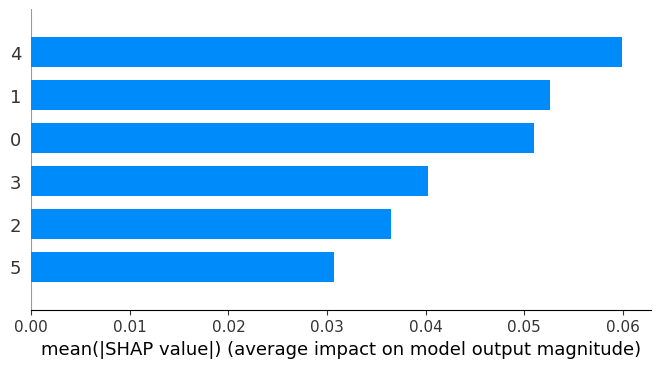

In [97]:
# Primera forma de visualizar los SHAP values LOF
shap.summary_plot(lof_shap_values, X_Test, plot_type='bar')

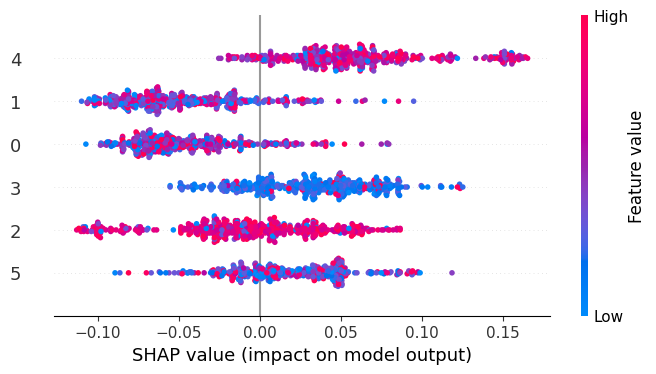

In [98]:
shap.summary_plot(lof_shap_values, X_Test.sample(500))

# Iforest
- Preparación de la data
- OrdinalEncoder
- StandardScaler
- SimpleImputer
- RandomOverSampler
- Seleccion y extracción de de caracteriticas por correlación
- PCA
- Isolation Forest

In [64]:
from numpy import unique
from numpy import where
from sklearn.datasets import make_classification
from sklearn.ensemble import IsolationForest
from matplotlib import pyplot
ifor_1 = Pipeline(steps=[('preprocessor_3_pca',preprocessor_3),
                           ('ifor',IsolationForest(max_samples=300, contamination=0.1))])
ifor_1

Pipeline(steps=[('preprocessor_3_pca',
                 Pipeline(steps=[('prepro_2_del',
                                  Pipeline(steps=[('prepro_1_num_cat',
                                                   ColumnTransformer(transformers=[('number',
                                                                                    Pipeline(steps=[('impute',
                                                                                                     SimpleImputer(fill_value=-1,
                                                                                                                   strategy='constant'))]),
                                                                                    ['delta_time',
                                                                                     'port_src',
                                                                                     'port_dst',
                                                                                     'frame_len',
                                                                                     'udp_len',
                                                                                     'ip_ttl',
                                                                                     'icmp_type',
                                                                                     'tos',
                                                                                     'ip_flags_rb',
                                                                                     'ip_flags_df',
                                                                                     'ip_flags_m...
                                                                        'number__tcp_flags_res',
                                                                        'number__tcp_flags_ns',
                                                                        'number__tcp_flags_cwr',
                                                                        'number__tcp_flags_ecn',
                                                                        'number__tcp_flags_urg',
                                                                        'number__tcp_flags_ack',
                                                                        'number__tcp_flags_push',
                                                                        'number__tcp_flags_reset',
                                                                        'number__tcp_flags_syn',
                                                                        'number__tcp_flags_fin']))])),
                                 ('scaler', StandardScaler()),
                                 ('pca', PCA(n_components=12))])),
                ('ifor', IsolationForest(contamination=0.1, max_samples=300))])

In [65]:
ind_train = df.loc[df['tipo_ataque'] == 'Normal'].index
cantidad = len(ind_train)*0.8
ind_train = ind_train[:int(cantidad)]

#print(cantidad)
X_train = df.loc[df['tipo_ataque'] == 'Normal'].head(int(cantidad)).drop(['label','tipo_ataque','tipo_ataque2','protocols'],axis=1)
print(X_train.tail(5))
y_train = df.loc[df['tipo_ataque'] == 'Normal'].head(int(cantidad))['label']
print(y_train)

        delta_time  port_src  port_dst  frame_len  udp_len  ip_ttl  icmp_type  \
142228    0.000002       0.0       0.0        837     -1.0   127.0       -1.0   
82150     0.000003      80.0      80.0        296     -1.0   127.0       -1.0   
105168    0.000003     365.0     565.0         60     26.0   127.0       -1.0   
118420    0.000012    8080.0      80.0       1418     -1.0   127.0       -1.0   
151678    0.000002       0.0       0.0        843     -1.0   127.0       -1.0   

        tos  ip_flags_rb  ip_flags_df  ...  tcp_flags_res  tcp_flags_ns  \
142228  0.0          0.0          0.0  ...            0.0           0.0   
82150   0.0          0.0          0.0  ...            0.0           0.0   
105168  0.0          0.0          0.0  ...           -1.0          -1.0   
118420  0.0          0.0          0.0  ...            0.0           0.0   
151678  0.0          0.0          0.0  ...            0.0           0.0   

        tcp_flags_cwr  tcp_flags_ecn  tcp_flags_urg  tcp_flags

In [66]:
last_ind = ind_train[-1]
copy = df.loc[df['tipo_ataque'] == 'Normal'].loc[last_ind:].drop([last_ind],axis=0).index
ind_test = df.loc[df['tipo_ataque'] != 'Normal'].index
ind_test =ind_test.append(copy)
X_test = df.iloc[df.index.get_indexer(ind_test.difference(ind_train, sort=False))].drop(['label','tipo_ataque','tipo_ataque2','protocols'],axis=1)
print(X_test.head(5))
y_test = df.iloc[df.index.get_indexer(ind_test.difference(ind_train, sort=False))]['label']
print(y_test.head(5))

        delta_time  port_src  port_dst  frame_len  udp_len  ip_ttl  icmp_type  \
240305    0.000001    3179.0      80.0         60      8.0    64.0       -1.0   
339943    0.000982      -2.0      -2.0         60     -2.0    64.0        8.0   
230914    0.003414   55550.0    9100.0         60     -1.0    58.0       -1.0   
276121    0.000002   44174.0      80.0        154     -1.0    64.0       -1.0   
261364    0.000002   35198.0      80.0        154     -1.0    64.0       -1.0   

        tos  ip_flags_rb  ip_flags_df  ...  tcp_flags_res  tcp_flags_ns  \
240305  0.0          0.0          0.0  ...           -1.0          -1.0   
339943  0.0          0.0          0.0  ...           -2.0          -2.0   
230914  0.0          0.0          0.0  ...            0.0           0.0   
276121  0.0          0.0          0.0  ...            0.0           0.0   
261364  0.0          0.0          0.0  ...            0.0           0.0   

        tcp_flags_cwr  tcp_flags_ecn  tcp_flags_urg  tcp_flags

In [67]:
model = ifor_1.fit(X_train)
model

Pipeline(steps=[('preprocessor_3_pca',
                 Pipeline(steps=[('prepro_2_del',
                                  Pipeline(steps=[('prepro_1_num_cat',
                                                   ColumnTransformer(transformers=[('number',
                                                                                    Pipeline(steps=[('impute',
                                                                                                     SimpleImputer(fill_value=-1,
                                                                                                                   strategy='constant'))]),
                                                                                    ['delta_time',
                                                                                     'port_src',
                                                                                     'port_dst',
                                                                                     'frame_len',
                                                                                     'udp_len',
                                                                                     'ip_ttl',
                                                                                     'icmp_type',
                                                                                     'tos',
                                                                                     'ip_flags_rb',
                                                                                     'ip_flags_df',
                                                                                     'ip_flags_m...
                                                                        'number__tcp_flags_res',
                                                                        'number__tcp_flags_ns',
                                                                        'number__tcp_flags_cwr',
                                                                        'number__tcp_flags_ecn',
                                                                        'number__tcp_flags_urg',
                                                                        'number__tcp_flags_ack',
                                                                        'number__tcp_flags_push',
                                                                        'number__tcp_flags_reset',
                                                                        'number__tcp_flags_syn',
                                                                        'number__tcp_flags_fin']))])),
                                 ('scaler', StandardScaler()),
                                 ('pca', PCA(n_components=12))])),
                ('ifor', IsolationForest(contamination=0.1, max_samples=300))])

In [68]:
model

Pipeline(steps=[('preprocessor_3_pca',
                 Pipeline(steps=[('prepro_2_del',
                                  Pipeline(steps=[('prepro_1_num_cat',
                                                   ColumnTransformer(transformers=[('number',
                                                                                    Pipeline(steps=[('impute',
                                                                                                     SimpleImputer(fill_value=-1,
                                                                                                                   strategy='constant'))]),
                                                                                    ['delta_time',
                                                                                     'port_src',
                                                                                     'port_dst',
                                                                                     'frame_len',
                                                                                     'udp_len',
                                                                                     'ip_ttl',
                                                                                     'icmp_type',
                                                                                     'tos',
                                                                                     'ip_flags_rb',
                                                                                     'ip_flags_df',
                                                                                     'ip_flags_m...
                                                                        'number__tcp_flags_res',
                                                                        'number__tcp_flags_ns',
                                                                        'number__tcp_flags_cwr',
                                                                        'number__tcp_flags_ecn',
                                                                        'number__tcp_flags_urg',
                                                                        'number__tcp_flags_ack',
                                                                        'number__tcp_flags_push',
                                                                        'number__tcp_flags_reset',
                                                                        'number__tcp_flags_syn',
                                                                        'number__tcp_flags_fin']))])),
                                 ('scaler', StandardScaler()),
                                 ('pca', PCA(n_components=12))])),
                ('ifor', IsolationForest(contamination=0.1, max_samples=300))])

In [69]:
# Entrenar Isolation Forest
model = ifor_1.fit(X_train)

# Calcular puntuaciones de anomalía
scores = ifor_1.decision_function(X_test)

# Umbral más estricto: detecta menos anomalías
umbral = -0.05

# 1 = ataque/anomalía, 0 = normal
predicciones = (scores < umbral).astype(int)

X_test['Trans_predict'] = predicciones

In [70]:
# Transformar los datos de prueba
pp1_array = preprocessor_2.transform(X_test)

pp1_ = pd.DataFrame(
    pp1_array,
    index=X_test.index
)

# Unir características, predicciones y etiquetas reales
X_ = pd.concat(
    [
        pp1_,
        X_test[['Trans_predict']],
        y_test
    ],
    axis=1
)

X_ = X_.rename(columns={'label': 'tipo_ataque'})

In [71]:
# NOTA
y_test.value_counts()

label
1    144000
0     40000
Name: count, dtype: int64

In [72]:
X_test['Trans_predict'] = predicciones

In [73]:
# Eliminar la predicción anterior antes de volver a usar el modelo
X_test_model = X_test.drop(
    columns=['Trans_predict'],
    errors='ignore'
)

# Usar el pipeline Isolation Forest que sí existe
scores = ifor_1.decision_function(X_test_model)

umbral = -0.05

predicciones = (scores < umbral).astype(int)

X_test['Trans_predict'] = predicciones

print(X_test['Trans_predict'].value_counts())

Trans_predict
1    147200
0     36800
Name: count, dtype: int64


In [74]:
pp1_=preprocessor_2.fit_transform(X_test)
pp1_.index = X_test.index
pp1_

,number__delta_time,number__port_src,number__port_dst,number__frame_len,number__udp_len,number__ip_ttl,number__icmp_type,number__tos,number__ip_flags_df,number__ip_flags_mf,number__tcp_flags_ns,number__tcp_flags_syn
240305,0.000001,3179.0,80.0,60.0,8.0,64.0,-1.0,0.0,0.0,0.0,-1.0,-1.0
339943,0.000982,-2.0,-2.0,60.0,-2.0,64.0,8.0,0.0,0.0,0.0,-2.0,-2.0
230914,0.003414,55550.0,9100.0,60.0,-1.0,58.0,-1.0,0.0,0.0,0.0,0.0,1.0
276121,0.000002,44174.0,80.0,154.0,-1.0,64.0,-1.0,0.0,0.0,0.0,0.0,1.0
261364,0.000002,35198.0,80.0,154.0,-1.0,64.0,-1.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...
34575,0.000008,3456.0,80.0,680.0,646.0,127.0,-1.0,0.0,0.0,0.0,-1.0,-1.0
103397,0.000001,365.0,565.0,60.0,26.0,127.0,-1.0,0.0,0.0,0.0,-1.0,-1.0
142792,0.000006,3456.0,80.0,918.0,884.0,127.0,-1.0,0.0,0.0,0.0,-1.0,-1.0
72922,0.000016,80.0,80.0,761.0,-1.0,127.0,-1.0,0.0,0.0,0.0,0.0,0.0


In [75]:
X_ = pd.concat([pp1_,X_test['Trans_predict'],y_test],axis=1)
X_.head(5)
X_=X_.rename(columns={'label':'tipo_ataque'})

In [76]:
metricas.metricas(X_, 'tipo_ataque', 'Trans_predict')
print('Rendimiento de Gastos Generales:')
print(f"tiempo:--- {time.time() - start_time} Segundos ---")
print('tiempo_cpu', t_cpu)
print('%_cpu', '%.2f%%' % cpu_usage)
print('%_mem', '%.2f%%' % mem_usage)
print ('consumo de disco', '%.2f%%' % disco2[3])

              precision    recall  f1-score   support

           0       1.00      0.92      0.96     40000
           1       0.98      1.00      0.99    144000

    accuracy                           0.98    184000
   macro avg       0.99      0.96      0.97    184000
weighted avg       0.98      0.98      0.98    184000

Purity  0.9826
homogeneity_score:  0.83982
completeness_score:  0.87873
v_measure_score:  0.85883
adjusted_mutual_info_score:  0.85883
Rendimiento de Gastos Generales:
tiempo:--- 1495.3757972717285 Segundos ---
tiempo_cpu scputimes(user=1182.578125, system=733.875, idle=13015.796875, interrupt=43.515625, dpc=40.359375)
%_cpu 1.90%
%_mem 67.40%
consumo de disco 54.90%


In [77]:
diag_iforest = pd.DataFrame({
    'Trans_predict': X_['Trans_predict'],
    'tipo_ataque2': df.loc[X_.index, 'tipo_ataque2']
})

resumen = diag_iforest.groupby('tipo_ataque2')['Trans_predict'].agg(['mean', 'count'])
resumen.columns = ['tasa_deteccion', 'total_muestras']
print(resumen)

                tasa_deteccion  total_muestras
tipo_ataque2                                  
DDoS_TCP              1.000000           40000
DDoS_UDP              1.000000           40000
ICMP_Flood            1.000000           12000
Normal                0.080025           40000
Reconnaissance        0.999975           40000
UDP_Flood             1.000000           12000


In [78]:
matriz1 = metricas.matriz(X_, 'tipo_ataque', 'Trans_predict')
matriz1[0]


1
         Positive Negative
Positive   143999        1
Negative     3201  36799.0

0
         Positive  Negative
Positive    36799      3201
Negative        1  143999.0


,Cantidad,coincidencia,% prediccion,total prediciones
0,144000,143999,0.999993,147200
1,40000.0,36799.0,0.919975,36800.0


In [79]:
matriz1[1]

,tp,fp,fn,tn,tp+fn,tp+fp,fn+tn,fp+tn,recall,precision,F1
tipo_ataque,,,,,,,,,,,
1,143999,3201,1,36799.0,144000,147200,36800.0,40000.0,0.999993,0.978254,0.989004
0,36799,1,3201,143999.0,40000,36800,147200.0,144000.0,0.919975,0.999973,0.958307


In [80]:
# datos para realizar las metricas internas
preprocessor_3.fit(X_test)
pp3 = preprocessor_3.transform(X_test)
# #Con PCA
pp3 = pd.DataFrame(pp3, index=X_test.index)
# #Sin PCA
# pp3 = pd.DataFrame(pp3, index=X.index,columns=pp1.columns)
pp3

,0,1,2,3,4,5,6,7,8,9,10,11
240305,0.302156,-0.636279,-1.057674,-0.111655,-0.115968,-0.428369,-0.409586,-0.024421,-0.718839,-0.023614,0.015539,0.117676
339943,-0.059025,-3.258868,-2.666937,0.450788,-0.475942,3.731923,0.825596,-0.264934,-0.051457,0.073596,0.113107,-0.015963
230914,-1.238900,1.788739,0.379648,0.157919,0.173765,0.094508,0.432492,-0.275125,0.387070,-0.167558,0.030145,-0.023495
276121,-0.726878,1.549927,0.324702,-0.566686,-0.301483,0.174371,0.161138,-0.050950,0.107434,-0.109874,0.001471,-0.071103
261364,-0.573987,1.391406,0.310312,-0.527610,-0.345123,0.196223,-0.032880,-0.071803,-0.203780,-0.172039,0.009350,-0.096762
...,...,...,...,...,...,...,...,...,...,...,...,...
34575,2.447223,-1.448434,1.045423,-0.677331,0.659393,-0.155134,0.293045,0.036524,0.162983,-0.475915,-0.037579,0.042399
103397,1.281694,-0.888895,-0.606385,-0.060981,-0.249954,-0.278084,-1.154349,-0.112940,0.370168,-0.957069,-0.074977,0.076121
142792,2.911379,-1.684271,1.680679,-0.898437,1.014362,-0.104077,0.819292,0.084567,0.042991,-0.299101,-0.021290,0.025633
72922,1.647382,-0.041866,1.260034,-0.310531,-0.702961,0.426868,-1.452274,-0.211757,0.061209,0.150073,-0.017845,0.143974


In [81]:
sh,chs,dbs=metricas.metrica_internas(pp3,X_['Trans_predict'])
print(f'Silhouette: {sh}')
print(f'Calinski: {chs}')
print(f'Davies: {dbs}')

Silhouette: 0.40982
Calinski: 39712.52524
Davies: 1.41686


In [82]:
pp1_ = preprocessor_2.transform(X_test_model)
pp1_ = pd.DataFrame(pp1_, index=X_test.index)

X_ = pd.concat(
    [pp1_, X_test[['Trans_predict']], y_test],
    axis=1
).rename(columns={'label': 'tipo_ataque'})

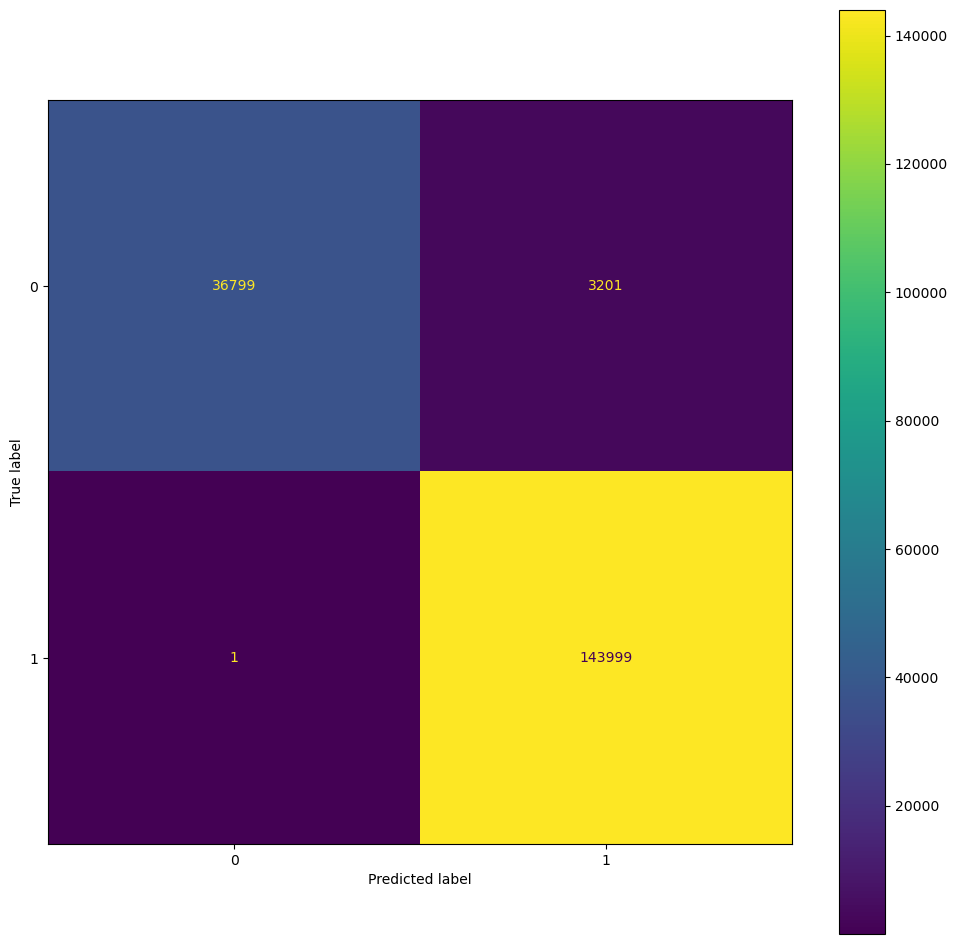

In [83]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
la_matriz=[0,1]
cm = confusion_matrix(X_['tipo_ataque'], X_['Trans_predict'])
disp = ConfusionMatrixDisplay(cm,display_labels=la_matriz)
fig, ax = plt.subplots(figsize=(12,12))
disp.plot(ax=ax)

In [84]:
# Explicabilidad con TreeShap
Ifor_explainer = shap.Explainer(model_.fit_predict, X_Test.sample(500))

In [85]:
#Calcular los Shap Values
Ifor_shap_values = Ifor_explainer(X_Test.sample(500))

PermutationExplainer explainer: 501it [1:19:45,  9.57s/it]                                                             


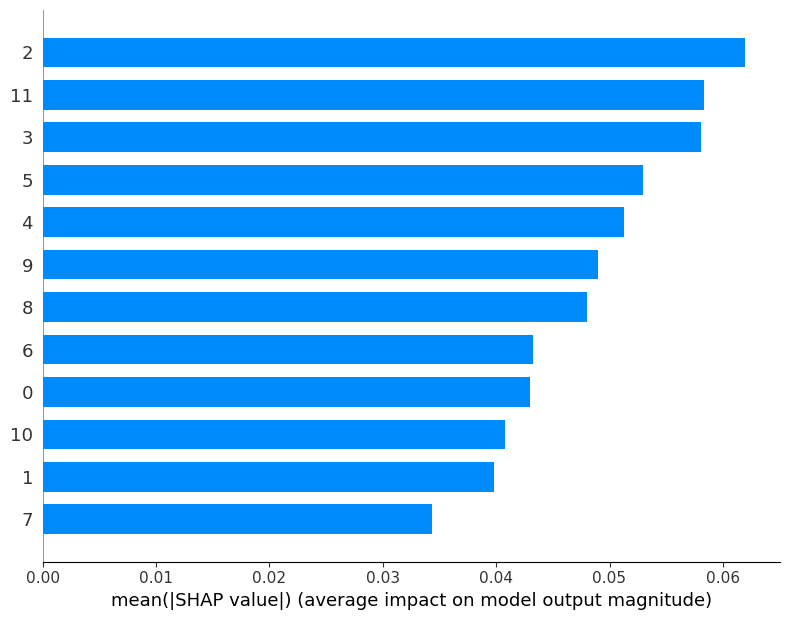

In [86]:
# Primera forma de visualizar los SHAP values kMeans
shap.summary_plot(Ifor_shap_values, X_Test, plot_type='bar')

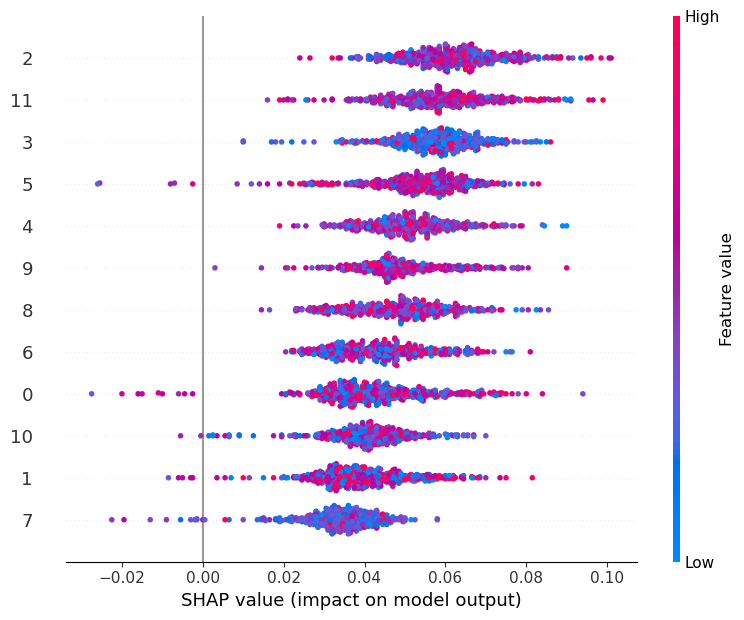

In [87]:
# Segunda Forma de Calcular los SHAP values LOF
shap.summary_plot(Ifor_shap_values, X_Test.sample(500))

In [88]:
pp1_ = preprocessor_2.transform(
    X_test.drop(columns=['Trans_predict'], errors='ignore')
)

pp1_ = pd.DataFrame(pp1_, index=X_test.index)

X_ = pd.concat(
    [pp1_, X_test[['Trans_predict']], y_test],
    axis=1
).rename(columns={'label': 'tipo_ataque'})

metricas.metricas(X_, 'tipo_ataque', 'Trans_predict')

              precision    recall  f1-score   support

           0       1.00      0.92      0.96     40000
           1       0.98      1.00      0.99    144000

    accuracy                           0.98    184000
   macro avg       0.99      0.96      0.97    184000
weighted avg       0.98      0.98      0.98    184000

Purity  0.9826
homogeneity_score:  0.83982
completeness_score:  0.87873
v_measure_score:  0.85883
adjusted_mutual_info_score:  0.85883


In [89]:
import joblib

joblib.dump(
    {
        'modelo': ifor_1,
        'umbral': -0.05
    },
    'iforest_pipeline_umbral_005.pkl'
)

print('Modelo IForest guardado correctamente')

Modelo IForest guardado correctamente


In [121]:
#23/11
#'list_iforest.txt' 'list_lof.txt'
#ifores_EJERCICIO10_.csv 

# df2.to_csv('iforest_EJERCICIO10_.csv')

In [90]:
pip show joblib

Name: joblib
Version: 1.5.3
Summary: Lightweight pipelining with Python functions
Home-page: https://joblib.readthedocs.io
Author: 
Author-email: Gael Varoquaux <gael.varoquaux@normalesup.org>
License-Expression: BSD-3-Clause
Location: C:\Users\Usuario\anaconda3\envs\ids-ml\Lib\site-packages
Requires: 
Required-by: imbalanced-learn, pynndescent, scikit-learn
Note: you may need to restart the kernel to use updated packages.


In [91]:
pip show scikit-learn

Name: scikit-learn
Version: 1.6.1
Summary: A set of python modules for machine learning and data mining
Home-page: https://scikit-learn.org
Author: 
Author-email: 
License: BSD 3-Clause License

 Copyright (c) 2007-2024 The scikit-learn developers.
 All rights reserved.

 Redistribution and use in source and binary forms, with or without
 modification, are permitted provided that the following conditions are met:

 * Redistributions of source code must retain the above copyright notice, this
   list of conditions and the following disclaimer.

 * Redistributions in binary form must reproduce the above copyright notice,
   this list of conditions and the following disclaimer in the documentation
   and/or other materials provided with the distribution.

 * Neither the name of the copyright holder nor the names of its
   contributors may be used to endorse or promote products derived from
   this software without specific prior written permission.

 THIS SOFTWARE IS PROVIDED BY THE COPYR

In [92]:
pip show pyod

Note: you may need to restart the kernel to use updated packages.


# KNN

In [91]:
from pyod.models.knn import KNN
from sklearn import metrics
import psutil
import time


#start_time=time.time()
#psutil.cpu_times()
#psutil.virtual_memory()
#psutil.disk_partitions()

#t_cpu = psutil.cpu_times()
#cpu_usage = psutil.cpu_percent(1)
#mem_usage = psutil.virtual_memory().percent
#disco2 = psutil.disk_usage('/')


knntc=Pipeline(steps=[('preprocessor_3_pca',preprocessor_3),
                           ('knn', KNN(contamination=0.1))])
model_knn=knntc.fit(X_train)

# Training data
y_train_scores_knn = knntc.decision_function(X_train)
y_train_pred_knn = knntc.predict(X_train)

# Test data
y_test_scores_knn = knntc.decision_function(X_test)
y_test_pred_knn = knntc.predict(X_test) # outlier labels (0 or 1)

def count_stat(vector):
    # Because it is '0' and '1', we can run a count statistic.
    unique, counts = np.unique(vector, return_counts=True)
    return dict(zip(unique, counts))

print("The training data:", count_stat(y_train_pred_knn))
print("The training data:", count_stat(y_test_pred_knn))
# Threshold for the defined comtanimation rate
print("The threshold for the defined contamination rate:" , knntc.named_steps['knn'].threshold_)

The training data: {np.int64(0): np.int64(145185), np.int64(1): np.int64(14815)}
The training data: {np.int64(0): np.int64(36963), np.int64(1): np.int64(103037)}
The threshold for the defined contamination rate: 0.004325668559891089


In [110]:
knntc

Pipeline(steps=[('preprocessor_3_pca',
                 Pipeline(steps=[('prepro_2_del',
                                  Pipeline(steps=[('prepro_1_num_cat',
                                                   ColumnTransformer(transformers=[('number',
                                                                                    Pipeline(steps=[('impute',
                                                                                                     SimpleImputer(fill_value=-1,
                                                                                                                   strategy='constant'))]),
                                                                                    ['delta_time',
                                                                                     'port_src',
                                                                                     'port_dst',
                                                                                     'frame_len',
                                                                                     'udp_len',
                                                                                     'ip_ttl',
                                                                                     'icmp_type',
                                                                                     'tos',
                                                                                     'ip_flags_rb',
                                                                                     'ip_flags_df',
                                                                                     'ip_flags_m...
                                                                        'number__tcp_flags_urg',
                                                                        'number__tcp_flags_ack',
                                                                        'number__tcp_flags_push',
                                                                        'number__tcp_flags_reset',
                                                                        'number__tcp_flags_syn',
                                                                        'number__tcp_flags_fin']))])),
                                 ('scaler', StandardScaler()),
                                 ('pca', PCA(n_components=6))])),
                ('knn',
                 KNN(algorithm='auto', contamination=0.1, leaf_size=30, method='largest',
  metric='minkowski', metric_params=None, n_jobs=1, n_neighbors=5, p=2,
  radius=1.0))])

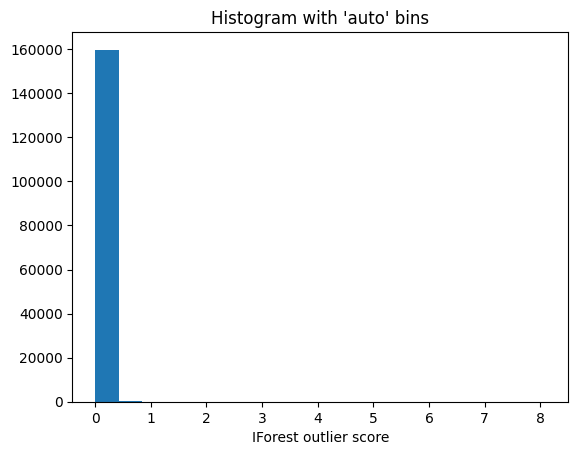

In [92]:
import matplotlib.pyplot as plt
plt.hist(y_train_scores_knn, bins='auto')  # arguments are passed to np.histogram
plt.title("Histogram with 'auto' bins")
plt.xlabel('IForest outlier score')
plt.show()

In [95]:
def pred_threshold(
    score, threshold):
    score = pd.Series(score)  # ✅ Convertir a Series si es un array
    Actual_pred = pd.DataFrame({'Pred': score})  
    Actual_pred['Pred'] = np.where(Actual_pred['Pred']<=threshold,0,1)
    Actual_pred=Actual_pred.reset_index(drop=True)
    return (Actual_pred)


In [93]:
# Test data
start_time = time.time()
psutil.cpu_times()
psutil.virtual_memory()
psutil.disk_partitions()

y_test_scores_knn1 = knntc.named_steps['knn'].decision_function(preprocessor_3.transform(X_test))

In [96]:
actual_pred_knn=pred_threshold(y_test_scores_knn1, 0.004325)
actual_pred_knn.isnull().sum()

Pred    0
dtype: int64

In [99]:
X_=X_test.copy()
X_['Trans_predict']=actual_pred_knn.values
X_['tipo_ataque']=y_test
X_
t_cpu = psutil.cpu_times()
cpu_usage = psutil.cpu_percent(1)
mem_usage = psutil.virtual_memory().percent
disco2 = psutil.disk_usage('/')
end_time=time.time()
total_time=end_time-start_time

In [100]:
metricas.metricas(X_)
print('Rendimiento de Gastos Generales:')
print(f"tiempo:--- {total_time} Segundos ---")
print('tiempo_cpu', t_cpu)
print('%_cpu', '%.2f%%' % cpu_usage)
print('%_mem', '%.2f%%' % mem_usage)
print ('consumo de disco', '%.2f%%' % disco2[3])

              precision    recall  f1-score   support

           0       0.98      0.90      0.94     40000
           1       0.96      0.99      0.98    100000

    accuracy                           0.97    140000
   macro avg       0.97      0.95      0.96    140000
weighted avg       0.97      0.97      0.96    140000

Purity  0.96528
homogeneity_score:  0.74893
completeness_score:  0.77624
v_measure_score:  0.76234
adjusted_mutual_info_score:  0.76233
Rendimiento de Gastos Generales:
tiempo:--- 322.6488540172577 Segundos ---
tiempo_cpu scputimes(user=10483.12, nice=20.64, system=8500.72, idle=2189570.47, iowait=328.91, irq=0.0, softirq=1028.08, steal=0.0, guest=0.0, guest_nice=0.0)
%_cpu 6.10%
%_mem 68.60%
consumo de disco 89.60%


In [101]:
pp1_=preprocessor_2.fit_transform(X_test)
pp1_.index = X_test.index
pp1_

,number__delta_time,number__port_src,number__port_dst,number__frame_len,number__udp_len,number__ip_ttl,number__tos,number__ip_flags_df,number__ip_flags_mf,number__tcp_flags_ns,number__tcp_flags_syn
287037,0.000000,55288.0,80.0,154.0,-1.0,64.0,0.0,0.0,0.0,0.0,1.0
271047,0.000002,34186.0,80.0,154.0,-1.0,64.0,0.0,0.0,0.0,0.0,1.0
241257,0.000000,4131.0,80.0,60.0,8.0,64.0,0.0,0.0,0.0,-1.0,-1.0
268157,0.000001,46623.0,80.0,154.0,-1.0,64.0,0.0,0.0,0.0,0.0,1.0
288710,0.000002,44405.0,80.0,154.0,-1.0,64.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...
149225,0.000008,3456.0,80.0,947.0,913.0,127.0,0.0,0.0,0.0,-1.0,-1.0
59604,0.055405,80.0,8080.0,1259.0,-1.0,127.0,0.0,0.0,0.0,0.0,0.0
101936,0.000002,80.0,80.0,1485.0,-1.0,127.0,0.0,0.0,0.0,0.0,0.0
44053,0.000002,80.0,80.0,506.0,472.0,127.0,0.0,0.0,0.0,-1.0,-1.0


In [102]:
# datos para realizar las metricas internas
preprocessor_3.fit(X_test)
pp3 = preprocessor_3.transform(X_test)
# #Con PCA
pp3 = pd.DataFrame(pp3, index=X_test.index)
# #Sin PCA
# pp3 = pd.DataFrame(pp3, index=X.index,columns=pp1.columns)
pp3

,0,1,2,3,4,5
287037,1.701034,-0.653613,-0.349884,-0.116820,0.063983,0.347375
271047,1.229408,-0.703946,-0.313262,-0.051783,0.079988,0.143795
241257,-1.011153,1.141401,-0.973072,-0.164742,0.401926,-1.335592
268157,1.507371,-0.674280,-0.334840,-0.090103,0.070561,0.263778
288710,1.457794,-0.679568,-0.330963,-0.083220,0.072268,0.242372
...,...,...,...,...,...,...
149225,-3.840144,-0.360062,-0.285732,-0.806785,-0.537871,0.249083
59604,-2.286782,-1.328712,2.900948,3.586895,1.567661,0.408074
101936,-2.150226,-1.999982,0.684896,0.216464,-0.095045,1.051033
44053,-2.947938,0.115737,-0.418335,-0.490481,-0.094235,-0.397119


In [103]:
import importlib
import metricas
importlib.reload(metricas)
sh,chs,dbs=metricas.metrica_internas(pp3,X_['Trans_predict'])
print(f'Silhouette: {sh}')
print(f'Calinski: {chs}')
print(f'Davies: {dbs}')

print('Rendimiento de Gastos Generales:')
print(f"tiempo:--- {time.time() - start_time} Segundos ---")
print('tiempo_cpu', t_cpu)
print('%_cpu', '%.2f%%' % cpu_usage)
print('%_mem', '%.2f%%' % mem_usage)
print ('consumo de disco', '%.2f%%' % disco2[3])

Silhouette: 0.50043
Calinski: 45888.14849
Davies: 1.23939
Rendimiento de Gastos Generales:
tiempo:--- 553.2861044406891 Segundos ---
tiempo_cpu scputimes(user=10483.12, nice=20.64, system=8500.72, idle=2189570.47, iowait=328.91, irq=0.0, softirq=1028.08, steal=0.0, guest=0.0, guest_nice=0.0)
%_cpu 6.10%
%_mem 68.60%
consumo de disco 89.60%


In [104]:
matriz1=metricas.matriz(X_)
matriz1[0]


1
         Positive Negative
Positive    99088      912
Negative     3949  36051.0

0
         Positive Negative
Positive    36051     3949
Negative      912  99088.0


,Cantidad,coincidencia,% prediccion,total prediciones
0,100000,99088,0.99088,103037
1,40000.0,36051.0,0.901275,36963.0


In [105]:
matriz1[1]

,tp,fp,fn,tn,tp+fn,tp+fp,fn+tn,fp+tn,recall,precision,F1
tipo_ataque,,,,,,,,,,,
1,99088,3949,912,36051.0,100000,103037,36963.0,40000.0,0.99088,0.961674,0.976059
0,36051,912,3949,99088.0,40000,36963,103037.0,100000.0,0.901275,0.975327,0.93684


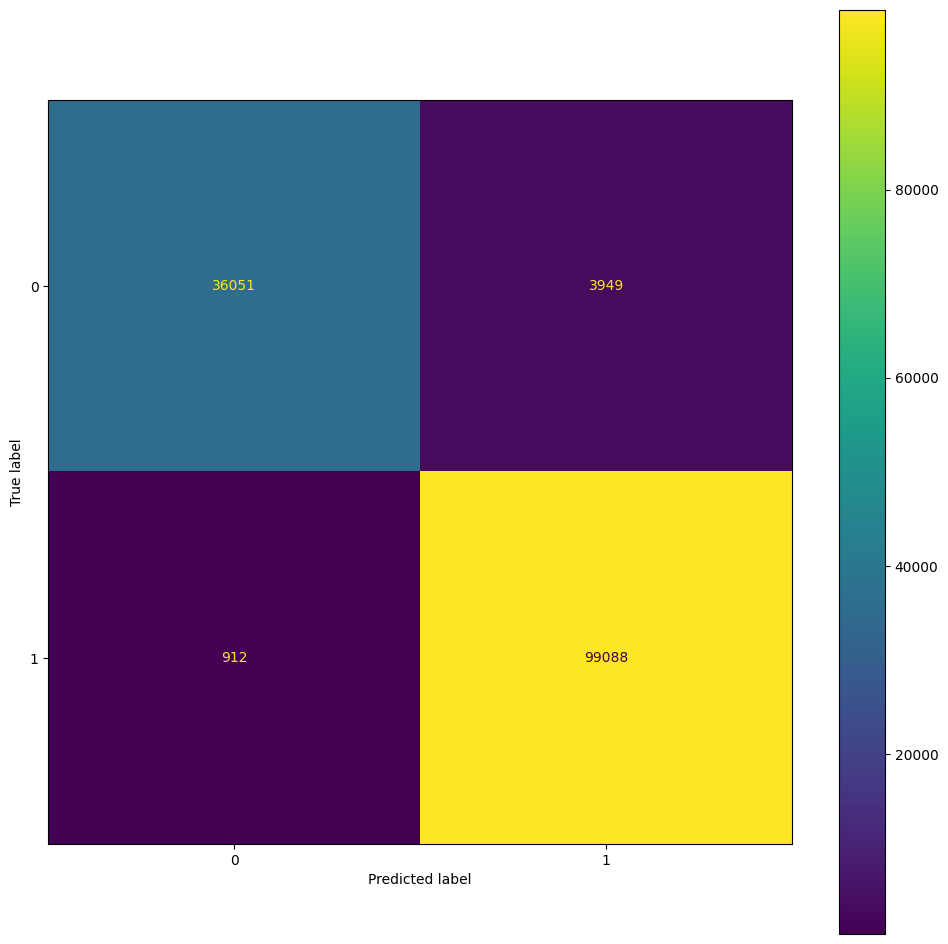

In [106]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
la_matriz=[0,1]
cm=confusion_matrix(X_['tipo_ataque'], X_['Trans_predict'])
disp = ConfusionMatrixDisplay(cm,display_labels=la_matriz)
fig, ax = plt.subplots(figsize=(12,12))
disp.plot(ax=ax)

model 1 AUC score: 0.9460775


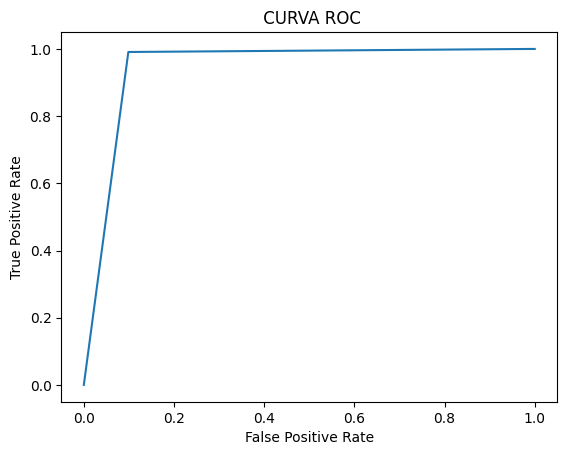

In [108]:
from sklearn.metrics import precision_score, recall_score, accuracy_score, f1_score, confusion_matrix, roc_curve,roc_auc_score
def plot_roc_curve(true_y, y_prob):
    fpr, tpr, thresholds = roc_curve(true_y, y_prob)
    plt.plot(fpr, tpr)
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(' CURVA ROC')
plot_roc_curve(X_['tipo_ataque'], X_['Trans_predict'])
print(f"model 1 AUC score: {roc_auc_score(X_['tipo_ataque'],X_['Trans_predict'])}")

In [109]:
print('= = ='*10,'12. Guardar el Modelo KNN ')
pickle_model('knn__EJERCICIO10_n_components6_fit.pkl', 'wb', model_knn)

= = == = == = == = == = == = == = == = == = == = = 12. Guardar el Modelo KNN 
Modelo knn__EJERCICIO10_n_components6_fit.pkl guardado.


# Autoencoder

In [1]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"  # Opcional: reduce logs
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"
os.environ["TF_XLA_FLAGS"] = "--tf_xla_enable_xla_devices=false"
os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"  # Evita errores con AVX/CPU optimizations

In [ ]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"
os.environ["TF_XLA_FLAGS"] = "--tf_xla_enable_xla_devices=false"
os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"

import tensorflow as tf

print("TF version:", tf.__version__)
print("GPU devices:", tf.config.list_physical_devices("GPU"))

a = tf.constant(10)
b = tf.constant(20)
print("a + b =", tf.add(a, b).numpy())


In [ ]:
from sklearn.base import BaseEstimator, ClassifierMixin
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam
import numpy as np

class AutoencoderClassifier(BaseEstimator, ClassifierMixin):
    def __init__(self, input_dim=None, n_classes=2, epochs=100, batch_size=32, verbose=0, patience=5):
        self.input_dim = input_dim
        self.n_classes = n_classes
        self.epochs = epochs
        self.batch_size = batch_size
        self.verbose = verbose
        self.patience = patience
        self.model = None

    def _build_model(self):
        input_layer = Input(shape=(self.input_dim,))
        encoded = Dense(64, activation='relu')(input_layer)
        encoded = Dense(32, activation='relu')(encoded)
        latent  = Dense(16, activation='relu', name='latent_space')(encoded)

        decoded = Dense(32, activation='relu')(latent)
        decoded = Dense(64, activation='relu')(decoded)
        reconstruction = Dense(self.input_dim, activation='sigmoid', name='reconstruction')(decoded)

        classifier = Dense(32, activation='relu')(latent)
        classifier = Dense(self.n_classes, activation='softmax', name='classification')(classifier)

        model = Model(inputs=input_layer, outputs=[reconstruction, classifier])
        model.compile(optimizer=Adam(),
                      loss={'reconstruction': 'mse', 'classification': 'categorical_crossentropy'},
                      loss_weights={'reconstruction': 0.5, 'classification': 1.0},
                      metrics={'classification': 'accuracy'})
        return model

    def fit(self, X, y):
        self.input_dim = X.shape[1]
        self.n_classes = len(set(y)) if len(y.shape) == 1 else y.shape[1]
        y_cat = to_categorical(y, num_classes=self.n_classes)
        self.model = self._build_model()

        early_stop = EarlyStopping(
            monitor='val_classification_accuracy',
            patience=self.patience,
            restore_best_weights=True,
            verbose=self.verbose > 0
        )

        self.model.fit(X, {'reconstruction': X, 'classification': y_cat},
                       validation_split=0.2,
                       epochs=self.epochs,
                       batch_size=self.batch_size,
                       verbose=self.verbose,
                       callbacks=[early_stop])
        return self

    def predict(self, X):
        _, y_pred = self.model.predict(X)
        return np.argmax(y_pred, axis=1)

    def predict_proba(self, X):
        _, y_pred = self.model.predict(X)
        return y_pred

In [ ]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

model = Sequential([
    Dense(64, activation='relu', input_shape=(20,)),
    Dense(3, activation='softmax')
])
model.compile(optimizer=Adam(), loss='categorical_crossentropy')
model.summary()

# OCSVM

In [99]:
from sklearn.svm import OneClassSVM

ocsvm=Pipeline(steps=[('preprocessor_3_pca',preprocessor_3),
                           ('ocsvm',OneClassSVM(kernel='rbf', gamma='auto', nu=0.1))])
model_ocsvm=ocsvm.fit(X_train)


In [100]:
y_test

254986    1
209653    1
220304    1
241429    1
278615    1
         ..
116498    0
44963     0
31673     0
147806    0
110368    0
Name: label, Length: 180000, dtype: int64

In [ ]:
scores_train = ocsvm.decision_function(X_test)
threshold = np.percentile(scores_train, 100 * 0)
test_scores = np.where(scores_train >= threshold,0,1)

In [70]:
test_scores = ocsvm.predict(X_test)
print(test_scores)
# Predict the labels (1 inlier, -1 outlier) of X according to LOF.
n_error_outliers = test_scores[test_scores == -1].size
n_error_test = test_scores[test_scores == 1].size
print(f'n_error_test {n_error_test}')
print(f'n_error_outliers {n_error_outliers}')

[-1 -1  1 ...  1  1  1]
n_error_test 79157
n_error_outliers 100843


In [ ]:
X_test['Trans_predict'] = test_scores
X_test

In [ ]:
X_test['Trans_predict'] = X_test['Trans_predict'].mask(X_test['Trans_predict'] == 1,0)
X_test['Trans_predict'] = X_test['Trans_predict'].mask(X_test['Trans_predict'] == -1,1)
X_test['Trans_predict']

In [ ]:
pp1_=preprocessor_2.fit_transform(X_test)
pp1_.index = X_test.index
pp1_

In [ ]:
X_ = pd.concat([pp1_,X_test['Trans_predict'],y_test],axis=1)
X_.head(5)
X_=X_.rename(columns={'label':'tipo_ataque'})

In [ ]:
metricas.metricas(X_)
print('Rendimiento de Gastos Generales:')
print(f"tiempo:--- {time.time() - start_time} Segundos ---")
print('tiempo_cpu', t_cpu)
print('%_cpu', '%.2f%%' % cpu_usage)
print('%_mem', '%.2f%%' % mem_usage)
print ('consumo de disco', '%.2f%%' % disco2[3])

In [88]:
matriz1=metricas.matriz(X_)
matriz1[0]


1
         Positive Negative
Positive     1416    98584
Negative      383  79617.0

0
         Positive Negative
Positive    79617      383
Negative    98584   1416.0


,Cantidad,coincidencia,% prediccion,total prediciones
0,100000,1416,0.01416,1799
1,80000.0,79617.0,0.995213,178201.0


In [89]:
matriz1[1]

,tp,fp,fn,tn,tp+fn,tp+fp,fn+tn,fp+tn,recall,precision,F1
tipo_ataque,,,,,,,,,,,
1,1416,383,98584,79617.0,100000,1799,178201.0,80000.0,0.01416,0.787104,0.02782
0,79617,98584,383,1416.0,80000,178201,1799.0,100000.0,0.995213,0.446782,0.616706


In [90]:
# datos para realizar las metricas internas
preprocessor_3.fit(X_test)
pp3 = preprocessor_3.transform(X_test)
# #Con PCA
pp3 = pd.DataFrame(pp3, index=X_test.index)
# #Sin PCA
# pp3 = pd.DataFrame(pp3, index=X.index,columns=pp1.columns)
pp3

,0,1,2,3,4,5
254986,-0.641580,1.155680,-0.884739,0.014893,-0.094964,-1.335622
209653,0.502475,2.798631,1.007398,0.576304,-0.507397,-0.929485
220304,2.262619,-0.248723,-0.544095,-0.123962,0.029861,0.004034
241429,-0.613668,1.160984,-0.892363,0.010418,-0.092190,-1.330536
278615,1.847057,-0.610572,-0.547389,-0.161675,0.128360,0.147690
...,...,...,...,...,...,...
116498,-1.260573,-1.627371,0.463828,0.010211,0.291426,1.083066
44963,2.224189,-0.394311,-0.650539,-0.166995,0.093878,0.031321
31673,-0.492525,-0.912421,0.113166,0.020902,0.152191,0.175154
147806,-2.449604,0.414123,-0.463150,-0.392886,-0.192979,-0.337007


In [91]:
X_

,number__delta_time,number__port_src,number__port_dst,number__frame_len,number__udp_len,number__ip_ttl,number__tos,number__ip_flags_df,number__ip_flags_mf,number__tcp_flags_ns,number__tcp_flags_syn,Trans_predict,tipo_ataque
254986,0.000000,3007.0,80.0,60.0,8.0,64.0,0.0,0.0,0.0,-1.0,-1.0,0,1
209653,0.006741,36529.0,40711.0,60.0,8.0,57.0,0.0,0.0,0.0,-1.0,-1.0,0,1
220304,0.000000,46997.0,3869.0,60.0,-1.0,43.0,0.0,0.0,0.0,0.0,1.0,0,1
241429,0.000001,4302.0,80.0,60.0,8.0,64.0,0.0,0.0,0.0,-1.0,-1.0,0,1
278615,0.000002,44880.0,80.0,154.0,-1.0,64.0,0.0,0.0,0.0,0.0,1.0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
116498,0.000009,8080.0,80.0,1398.0,-1.0,127.0,0.0,0.0,0.0,0.0,0.0,0,0
44963,0.000014,50919.0,1037.0,60.0,-1.0,51.0,0.0,0.0,0.0,0.0,1.0,0,0
31673,0.000002,80.0,80.0,296.0,-1.0,127.0,0.0,0.0,0.0,0.0,0.0,0,0
147806,0.000002,80.0,80.0,575.0,541.0,127.0,0.0,0.0,0.0,-1.0,-1.0,0,0


In [39]:
sh,chs,dbs=metricas.metrica_internas(pp3,X_['Trans_predict'])
print(f'Silhouette: {sh}')
print(f'Calinski: {chs}')
print(f'Davies: {dbs}')

Silhouette: 0.31037
Calinski: 42088.67225
Davies: 1.64926


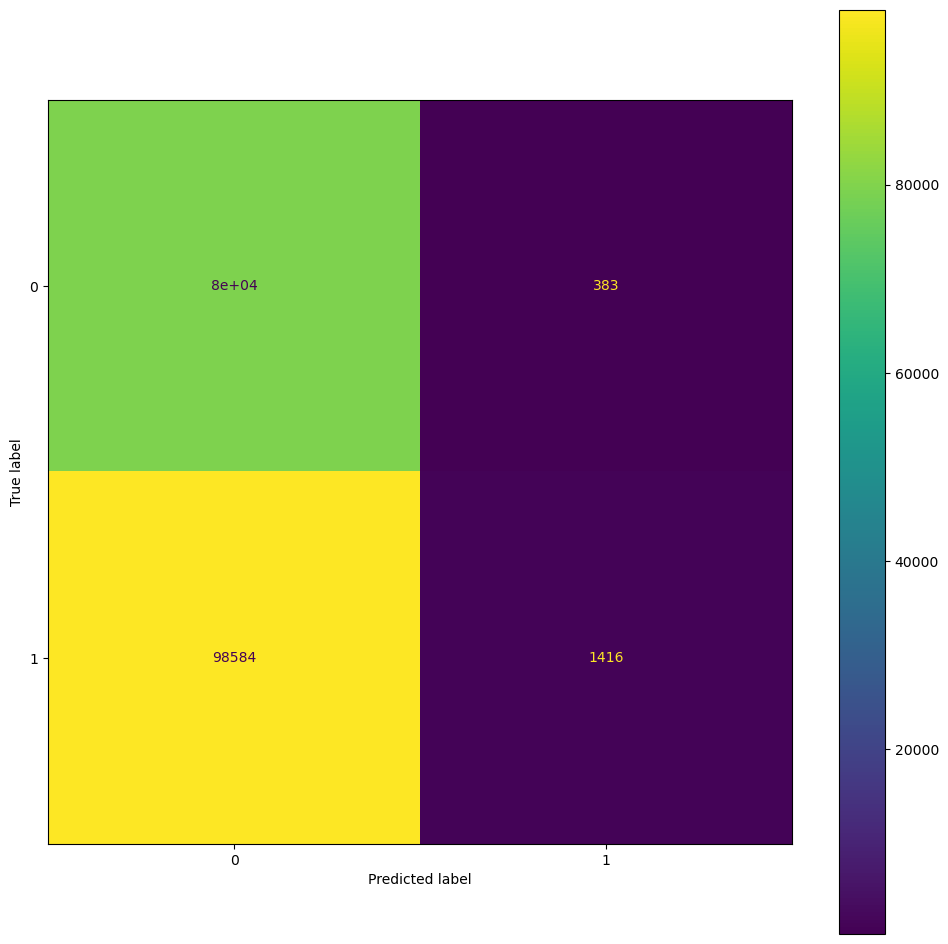

In [92]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
la_matriz=[0,1]
cm=confusion_matrix(X_['tipo_ataque'], X_['Trans_predict'])
disp = ConfusionMatrixDisplay(cm,display_labels=la_matriz)
fig, ax = plt.subplots(figsize=(12,12))
disp.plot(ax=ax)

In [43]:
print('= = ='*10,'12. Guardar el Modelo OCSVM ')
pickle_model('ocsvm__EJERCICIO10_n_components6_fit.pkl', 'wb', model_ocsvm)

= = == = == = == = == = == = == = == = == = == = = 12. Guardar el Modelo OCSVM 
Modelo ocsvm__EJERCICIO10_n_components6_fit.pkl guardado.


In [26]:
pp3O = preprocessor_3.transform(X_train)
pp3O

array([[-0.46489402,  1.37641691,  0.01628545,  0.16083303,  0.25138424,
        -0.9675406 ],
       [-0.99110691, -0.82043678, -0.29978263, -0.08864196, -0.03182399,
         0.60141021],
       [-0.20312789,  1.07734226, -0.03788106,  0.10138463,  0.16134353,
        -0.65201481],
       ...,
       [-0.23410113,  1.18384464, -0.05145391,  0.14727784,  0.21430444,
        -0.78444476],
       [-0.21763359,  2.039677  ,  1.9564704 , -2.14640856,  0.67958489,
         1.4457722 ],
       [-0.56446457,  1.45943184,  0.04541684,  0.16681404,  0.26734368,
        -1.04667178]])

In [28]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import OneClassSVM
param_grid = {
    'nu': [0.05, 0.1, 0.2, 0.3],
    'gamma': ['scale', 'auto', 0.1, 1, 10]
}
ocs = OneClassSVM(kernel='rbf')
grid = GridSearchCV(ocs, param_grid, cv=5, scoring='accuracy')  # usa tu métrica
grid.fit(pp3O)
print(grid.best_params_)

KeyboardInterrupt: 

# Autoencoder

In [29]:
# autoencoderclassifier.py

from sklearn.base import BaseEstimator, ClassifierMixin
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam
import numpy as np

class AutoencoderClassifier(BaseEstimator, ClassifierMixin):
    def __init__(self, input_dim=None, n_classes=2, epochs=100, batch_size=32, verbose=0, patience=5):
        self.input_dim = input_dim
        self.n_classes = n_classes
        self.epochs = epochs
        self.batch_size = batch_size
        self.verbose = verbose
        self.patience = patience
        self.model = None

    def _build_model(self):
        input_layer = Input(shape=(self.input_dim,))
        encoded = Dense(64, activation='relu')(input_layer)
        encoded = Dense(32, activation='relu')(encoded)
        latent  = Dense(16, activation='relu', name='latent_space')(encoded)

        decoded = Dense(32, activation='relu')(latent)
        decoded = Dense(64, activation='relu')(decoded)
        reconstruction = Dense(self.input_dim, activation='sigmoid', name='reconstruction')(decoded)

        classifier = Dense(32, activation='relu')(latent)
        classifier = Dense(self.n_classes, activation='softmax', name='classification')(classifier)

        model = Model(inputs=input_layer, outputs=[reconstruction, classifier])
        model.compile(optimizer=Adam(),
                      loss={'reconstruction': 'mse', 'classification': 'categorical_crossentropy'},
                      loss_weights={'reconstruction': 0.5, 'classification': 1.0},
                      metrics={'classification': 'accuracy'})
        return model

    def fit(self, X, y):
        self.input_dim = X.shape[1]
        self.n_classes = len(set(y)) if len(y.shape) == 1 else y.shape[1]
        y_cat = to_categorical(y, num_classes=self.n_classes)
        self.model = self._build_model()

        early_stop = EarlyStopping(
            monitor='val_classification_accuracy',
            mode='max',  # Esto evita el error anterior
            patience=self.patience,
            restore_best_weights=True,
            verbose=self.verbose > 0
        )

        self.model.fit(X, {'reconstruction': X, 'classification': y_cat},
                       validation_split=0.2,
                       epochs=self.epochs,
                       batch_size=self.batch_size,
                       verbose=self.verbose,
                       callbacks=[early_stop])
        return self

    def predict(self, X):
        _, y_pred = self.model.predict(X)
        return np.argmax(y_pred, axis=1)

    def predict_proba(self, X):
        _, y_pred = self.model.predict(X)
        return y_pred


In [30]:
from sklearn.pipeline import Pipeline

full_pipeline = Pipeline(steps=[
    ('preprocessor_3', preprocessor_3),  # Tu pipeline ya entrenable
    ('autoencoder_classifier', AutoencoderClassifier(epochs=50, batch_size=32))
])

In [40]:
y_train_enc = np.where(yAu_train == 'Normal', 0,
               np.where(yAu_train == 'DDoS_TCP', 1,
                 np.where(yAu_train == 'Reconnaissance', 2,
                   np.where(yAu_train == 'DDoS_UDP', 3,
                     -1  # valor por defecto si no coincide ninguna
                   )
                 )
               )
             )
y_train_enc

array([0, 0, 0, ..., 2, 2, 0])

In [41]:
# 1) Ajustar preprocesador
X_train_proc = preprocessor_3.fit_transform(XAu_train)

# 2) Ajustar el AutoencoderClassifier sobre los datos ya preprocesados
ae_clf = AutoencoderClassifier(epochs=50, batch_size=32)
ae_clf.fit(X_train_proc, y_train_enc)

AutoencoderClassifier(epochs=50, input_dim=6, n_classes=4)

In [44]:
import joblib

# — Pipeline de preprocesamiento —
joblib.dump(preprocessor_3, 'pipeline_preproc.pkl')

# — Modelo Keras (autoencoder + clasificador) —
autoenc_model = ae_clf.model
autoenc_model.save('autoencoder_model.keras')


In [51]:
# 1) Ajustar preprocesador
X_test_proc = preprocessor_3.transform(XAu_test)
y_test_enc = np.where(yAu_test == 'Normal', 0,
               np.where(yAu_test == 'DDoS_TCP', 1,
                 np.where(yAu_test == 'Reconnaissance', 2,
                   np.where(yAu_test == 'DDoS_UDP', 3,
                     -1  # valor por defecto si no coincide ninguna
                   )
                 )
               )
             )
y_test_enc


array([0, 0, 0, ..., 0, 0, 0])

In [52]:
len(XAu_test)

60000

In [53]:
len(X_test_proc)

60000

In [54]:
y_pred=ae_clf.predict(X_test_proc)

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step


In [58]:
XAu_test['Trans_predict']=y_pred

In [63]:
# Crea un DataFrame directamente de los tres arrays
X_ = pd.DataFrame(
    data = np.column_stack([X_test_proc, XAu_test['Trans_predict'], y_test_enc]),
    columns = [f'feat_{i}' for i in range(X_test_proc.shape[1])] 
              + ['Trans_predict', 'tipo_ataque']
)
X_

,feat_0,feat_1,feat_2,feat_3,feat_4,feat_5,Trans_predict,tipo_ataque
0,-0.270985,1.216262,-0.041371,0.149934,0.220632,-0.811850,0.0,0.0
1,-0.480271,2.171686,1.272410,-1.612002,0.703458,0.936372,0.0,0.0
2,-0.203098,1.078255,-0.038291,0.102599,0.162357,-0.652110,0.0,0.0
3,-0.991337,-0.821633,-0.298416,-0.089448,-0.032479,0.592678,0.0,0.0
4,-0.606610,1.416138,0.079599,0.126682,0.227773,-0.969504,0.0,0.0
...,...,...,...,...,...,...,...,...
59995,-1.902305,-0.708111,-0.295950,0.222269,-0.148821,0.297592,0.0,0.0
59996,-0.552592,1.451987,0.040790,0.166901,0.266239,-1.033523,0.0,0.0
59997,-0.084134,0.979027,-0.077636,0.096026,0.143536,-0.556200,0.0,0.0
59998,-3.289997,-0.556889,-0.254618,0.696797,-0.338344,-0.160656,0.0,0.0


In [64]:
metricas.metricas(X_)
print('Rendimiento de Gastos Generales:')
print(f"tiempo:--- {time.time() - start_time} Segundos ---")
print('tiempo_cpu', t_cpu)
print('%_cpu', '%.2f%%' % cpu_usage)
print('%_mem', '%.2f%%' % mem_usage)
print ('consumo de disco', '%.2f%%' % disco2[3])

              precision    recall  f1-score   support

         0.0       1.00      0.96      0.98     40000
         1.0       1.00      1.00      1.00      7993
         2.0       0.83      0.98      0.90      7971
         3.0       1.00      1.00      1.00      4036

    accuracy                           0.97     60000
   macro avg       0.96      0.99      0.97     60000
weighted avg       0.98      0.97      0.97     60000

Purity  0.97138
homogeneity_score:  0.91276
completeness_score:  0.88017
v_measure_score:  0.89617
adjusted_mutual_info_score:  0.89616
Rendimiento de Gastos Generales:
tiempo:--- 10312.161796569824 Segundos ---
tiempo_cpu scputimes(user=38103.953125, system=23628.28124999997, idle=223602.1875, interrupt=1819.28125, dpc=1774.421875)
%_cpu 25.20%
%_mem 82.00%
consumo de disco 88.20%


In [65]:
matriz1=metricas.matriz(X_)
matriz1[0]


0.0
         Positive Negative
Positive    38414     1586
Negative      131  19869.0

1.0
         Positive Negative
Positive     7992        1
Negative        1    52006

2.0
         Positive Negative
Positive     7841      130
Negative     1583    50446

3.0
         Positive Negative
Positive     4036        0
Negative        2  55962.0


,Cantidad,coincidencia,% prediccion,total prediciones
0,40000,38414,0.96035,38545
1,20000.0,19869.0,0.99345,21455.0


In [66]:
matriz1[1]

,tp,fp,fn,tn,tp+fn,tp+fp,fn+tn,fp+tn,recall,precision,F1
tipo_ataque,,,,,,,,,,,
0.0,38414,131,1586,19869.0,40000,38545,21455.0,20000.0,0.96035,0.996601,0.97814
1.0,7992,1,1,52006,7993,7993,52007,52007,0.999875,0.999875,0.999875
2.0,7841,1583,130,50446,7971,9424,50576,52029,0.983691,0.832025,0.901523
3.0,4036,2,0,55962.0,4036,4038,55962.0,55964.0,1.0,0.999505,0.999752


In [ ]:
full_pipeline.fit(XAu_train, yAu_train)

# Guardas el preprocesador + metadatos
import joblib
joblib.dump(full_pipeline, 'pipeline_preproc.pkl')

# Guardas el autoencoder
autoenc = full_pipeline.named_steps['autoencoder_classifier'].model
autoenc.save('autoencoder_model.h5')


In [67]:
preprocessor_3

Pipeline(steps=[('prepro_2_del',
                 Pipeline(steps=[('prepro_1_num_cat',
                                  ColumnTransformer(transformers=[('number',
                                                                   Pipeline(steps=[('impute',
                                                                                    SimpleImputer(fill_value=-1,
                                                                                                  strategy='constant'))]),
                                                                   ['delta_time',
                                                                    'port_src',
                                                                    'port_dst',
                                                                    'frame_len',
                                                                    'udp_len',
                                                                    'ip_ttl',
                                                                    'icmp_type',
                                                                    'tos',
                                                                    'ip_flags_rb',
                                                                    'ip_flags_df',
                                                                    'ip_flags_mf',
                                                                    'tcp_flags_res',
                                                                    'tcp_flags_ns',
                                                                    'tcp...
                                                       'number__ip_flags_rb',
                                                       'number__ip_flags_df',
                                                       'number__ip_flags_mf',
                                                       'number__tcp_flags_res',
                                                       'number__tcp_flags_ns',
                                                       'number__tcp_flags_cwr',
                                                       'number__tcp_flags_ecn',
                                                       'number__tcp_flags_urg',
                                                       'number__tcp_flags_ack',
                                                       'number__tcp_flags_push',
                                                       'number__tcp_flags_reset',
                                                       'number__tcp_flags_syn',
                                                       'number__tcp_flags_fin']))])),
                ('scaler', StandardScaler()), ('pca', PCA(n_components=6))])

In [45]:
# Validar nombres del pipeline antes de guardar
print("feature_names_in_ (primeros 20):", list(getattr(kmeans_1, 'feature_names_in_', [])[:20]))
try:
    pre = (
        kmeans_1.named_steps.get('preprocessor_3_pca')
        or kmeans_1.named_steps.get('preprocessor')
        or kmeans_1.named_steps.get('prepro_2_del')
    )
    if pre is not None and hasattr(pre, 'get_feature_names_out'):
        names = list(pre.get_feature_names_out())
        print("get_feature_names_out() (primeros 20):", names[:20])
    else:
        print("No se encontró preprocessor con get_feature_names_out()")
except Exception as e:
    print("Warning al consultar feature names:", e)

import pickle
with open("kmeans_reentrenado_v2_validated.pkl", "wb") as f:
    pickle.dump(kmeans_1, f)
print("Pipeline guardado en kmeans_reentrenado_v2_validated.pkl")

feature_names_in_ (primeros 20): ['delta_time', 'port_src', 'port_dst', 'frame_len', 'udp_len', 'ip_ttl', 'icmp_type', 'tos', 'ip_flags_rb', 'ip_flags_df', 'ip_flags_mf', 'tcp_flags_res', 'tcp_flags_ns', 'tcp_flags_cwr', 'tcp_flags_ecn', 'tcp_flags_urg', 'tcp_flags_ack', 'tcp_flags_push', 'tcp_flags_reset', 'tcp_flags_syn']
Warning al consultar feature names: Estimator del_columns does not provide get_feature_names_out. Did you mean to call pipeline[:-1].get_feature_names_out()?
Pipeline guardado en kmeans_reentrenado_v2_validated.pkl
